# Predictive Financial Disengagement and Retention Optimization in Digital Banking Using Deep Learning

### Reproducible experimental notebook

**Objective.** Predict whether a digital-banking customer will become financially disengaged within the defined 90-day outcome window using six months of behavioral history plus customer/account attributes.

**Deep-learning models compared:** DNN/MLP, LSTM, GRU, BiLSTM, BiGRU, 1D-CNN, CNN-LSTM, and CNN-GRU.

**Core design.** All models use the same six-month sequence (monthly logins, transaction count, average balance) and the same static predictors. Only the temporal encoder changes.

**Publication note.** The supplied dataset has 25,000 customer-level records and the target `disengaged_90d`. It is a supplied synthetic digital-banking dataset. The notebook therefore does not claim external validity or state-of-the-art performance. Those claims require evidence outside this notebook.

## 1. Environment and reproducibility

In [ ]:
import os, sys, random, time, warnings, re
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
SPLIT_SEED = 42
MAX_EPOCHS = 35
BATCH_SIZE = 256
PATIENCE = 7
LEARNING_RATE = 1e-3
OUTPUT_DIR = "q1_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass

set_seed()
print("Python:", sys.version.split()[0])
print("CPU mode requested; GPU will be disabled.")

Python: 3.13.15
CPU mode requested; GPU will be disabled.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

try:
    tf.config.threading.set_intra_op_parallelism_threads(max(1, min(4, os.cpu_count() or 2)))
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass

print("TensorFlow:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Visible GPUs: []


## 2. Data loading and integrity audit

In [ ]:
DATA_PATH = "digital_banking_disengagement_dataset.xlsx"
TARGET = "disengaged_90d"

df = pd.read_excel(DATA_PATH)

print("="*80)
print("DATASET AUDIT")
print("="*80)
print("Shape:", df.shape)
print("Missing cells:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique customers:", int(df["customer_id"].nunique()))
print("\nTarget:")
print(df[TARGET].value_counts().sort_index())
print("Disengagement rate:", round(df[TARGET].mean(), 4))

assert TARGET in df.columns
assert df["customer_id"].nunique() == len(df)
assert df[TARGET].isin([0,1]).all()
assert df.isna().sum().sum() == 0

DATASET AUDIT
Shape: (25000, 54)
Missing cells: 0
Duplicate rows: 0
Unique customers: 25000

Target:
disengaged_90d
0    19901
1     5099
Name: count, dtype: int64
Disengagement rate: 0.204


In [ ]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
})
display(audit)
print("Categorical:", df.select_dtypes(include=["object","string"]).columns.tolist())

,dtype,missing,unique
customer_id,object,0,25000
age,int64,0,63
gender,object,0,3
region,object,0,3
occupation,object,0,5
annual_income,int64,0,1008
tenure_months,int64,0,187
account_type,object,0,4
credit_score,int64,0,443
num_products,int64,0,6


Categorical: ['customer_id', 'gender', 'region', 'occupation', 'account_type', 'device_type', 'retention_intervention']


## 3. Exploratory data analysis

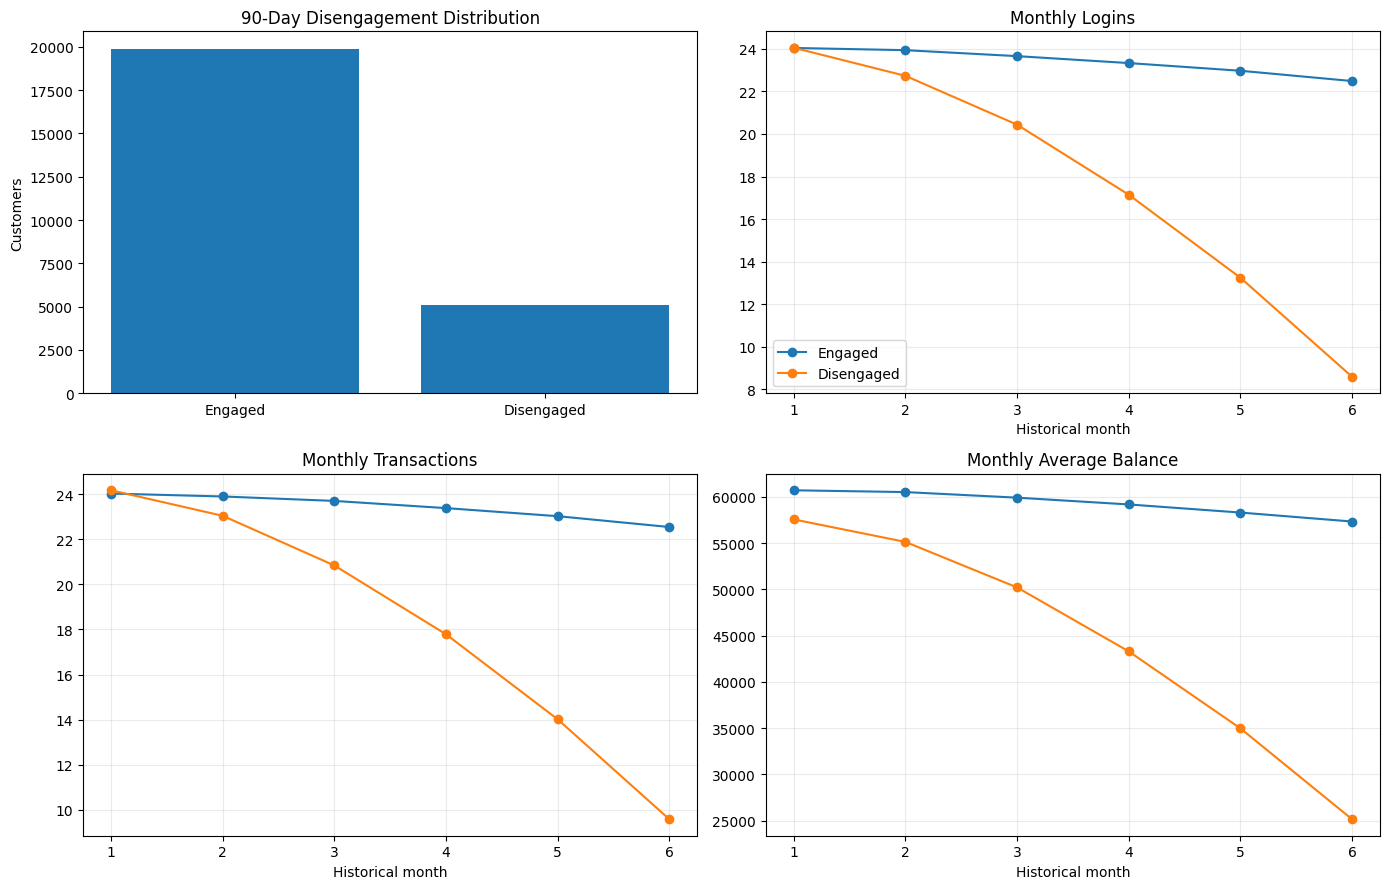

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(14,9))

counts = df[TARGET].value_counts().reindex([0,1])
axes[0,0].bar(["Engaged","Disengaged"], counts.values)
axes[0,0].set_title("90-Day Disengagement Distribution")
axes[0,0].set_ylabel("Customers")

months = np.arange(1,7)
for prefix, ax, title in [
    ("logins_m", axes[0,1], "Monthly Logins"),
    ("txn_count_m", axes[1,0], "Monthly Transactions"),
    ("avg_balance_m", axes[1,1], "Monthly Average Balance")
]:
    for label, name in [(0,"Engaged"),(1,"Disengaged")]:
        cols=[f"{prefix}{m}" for m in months]
        ax.plot(months, df.loc[df[TARGET]==label,cols].mean().values, marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("Historical month")
    ax.grid(alpha=.25)

axes[0,1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_1_eda.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
num_cols_eda = df.select_dtypes(include=np.number).columns.drop(TARGET)
corr = df[num_cols_eda].corrwith(df[TARGET]).sort_values()
display(pd.DataFrame({"feature_target_pearson_r":corr}))

,feature_target_pearson_r
balance_trend_3m,-0.820937
login_trend_3m,-0.780187
txn_trend_3m,-0.765634
nps_score,-0.622890
app_rating,-0.495044
avg_session_duration_min,-0.454446
logins_m6,-0.451552
rewards_redeemed_6m,-0.417736
digital_payment_ratio,-0.387280
txn_count_m6,-0.384394


## 4. Prediction design and leakage control

The model information set contains six historical months of logins, transaction counts and average balances, plus customer/account/engagement variables in the supplied record.

Excluded from prediction:
- `customer_id` — identifier
- `disengaged_90d` — target
- `retention_intervention` — post-prediction retention action
- `offer_accepted` — post-prediction intervention outcome

Retention-intervention analysis later in the notebook is **observational**, not causal.

In [ ]:
SEQ_FEATURES = ["logins_m","txn_count_m","avg_balance_m"]
N_STEPS = 6
N_CHANNELS = 3

X_seq_raw = np.stack(
    [df[[f"{p}{m}" for m in range(1,7)]].to_numpy(dtype="float32")
     for p in SEQ_FEATURES], axis=-1
)
X_seq_raw[:,:,2] = np.log1p(np.clip(X_seq_raw[:,:,2], 0, None))

EXCLUDED = {"customer_id", TARGET, "retention_intervention", "offer_accepted"}
SEQ_COLS = [f"{p}{m}" for m in range(1,7) for p in SEQ_FEATURES]

static_df = df.drop(columns=list(EXCLUDED)+SEQ_COLS).copy()
for c in ["annual_income","avg_txn_value","fees_charged_3m"]:
    if c in static_df.columns:
        static_df[c] = np.log1p(np.clip(static_df[c].astype(float),0,None))

cat_cols = static_df.select_dtypes(include=["object","string"]).columns.tolist()
num_cols = [c for c in static_df.columns if c not in cat_cols]
y = df[TARGET].to_numpy(dtype="int32")

print("Sequence:", X_seq_raw.shape)
print("Static:", len(static_df.columns), "| numeric:", len(num_cols), "| categorical:", len(cat_cols))
print("Excluded:", sorted(EXCLUDED))

Sequence: (25000, 6, 3)
Static: 32 | numeric: 27 | categorical: 5
Excluded: ['customer_id', 'disengaged_90d', 'offer_accepted', 'retention_intervention']


In [ ]:
# DATA LEAKAGE & INFORMATION-SET AUDIT

print("=" * 90)
print("INFORMATION-SET AND DATA-LEAKAGE AUDIT")
print("=" * 90)


date_time_keywords = [
    "date", "time", "timestamp", "created",
    "updated", "period", "month", "year"
]

date_time_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in date_time_keywords)
]

print("\nPotential date/time columns:")
print(date_time_cols)



target_keywords = [
    "target",
    "disengag",
    "churn",
    "retention",
    "offer",
    "intervention",
    "outcome"
]

target_related_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in target_keywords)
]

print("\nPotential target/post-outcome related columns:")
print(target_related_cols)



numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns = [
    c for c in numeric_columns
    if c != TARGET
]

correlation_results = []

for col in numeric_columns:

    try:
        corr_value = df[col].corr(df[TARGET])
    except Exception:
        corr_value = np.nan

    correlation_results.append({
        "Feature": col,
        "Target_Correlation": corr_value,
        "Absolute_Correlation": abs(corr_value)
        if not pd.isna(corr_value) else np.nan
    })

leakage_corr_df = (
    pd.DataFrame(correlation_results)
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print("\nTop numerical features associated with target:")
display(
    leakage_corr_df.head(20).round(4)
)



high_corr = leakage_corr_df[
    leakage_corr_df["Absolute_Correlation"] >= 0.80
]

print("\nFeatures with |correlation| >= 0.80:")
display(high_corr.round(4))

if len(high_corr) == 0:
    print("No numerical feature has correlation >= 0.80 with the target.")



identical_to_target = []

for col in df.columns:

    if col == TARGET:
        continue

    try:
        if df[col].equals(df[TARGET]):
            identical_to_target.append(col)
    except Exception:
        pass

print("\nFeatures identical to target:")
print(identical_to_target)

assert len(identical_to_target) == 0, (
    "Potential direct target leakage detected!"
)



categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_leakage_rows = []

for col in categorical_columns:

    if col == TARGET:
        continue

    try:
        grouped = (
            df.groupby(col, dropna=False)[TARGET]
            .agg(["count", "mean"])
            .reset_index()
        )

        max_rate = grouped["mean"].max()
        min_rate = grouped["mean"].min()

        categorical_leakage_rows.append({
            "Feature": col,
            "Unique_Values": df[col].nunique(),
            "Min_Target_Rate": min_rate,
            "Max_Target_Rate": max_rate,
            "Rate_Range": max_rate - min_rate
        })

    except Exception:
        pass

categorical_leakage_df = pd.DataFrame(
    categorical_leakage_rows
).sort_values(
    "Rate_Range",
    ascending=False
)

print("\nCategorical target-separation audit:")
display(
    categorical_leakage_df.round(4)
)



EXPECTED_EXCLUSIONS = {
    "customer_id",
    TARGET,
    "retention_intervention",
    "offer_accepted"
}

print("\nExplicit exclusions:")
for col in sorted(EXPECTED_EXCLUSIONS):
    print(
        f"{'✓' if col in df.columns else '⚠'} {col}"
    )



model_candidate_columns = (
    set(static_df.columns)
    if "static_df" in globals()
    else set()
)

leakage_in_static = (
    EXPECTED_EXCLUSIONS.intersection(
        model_candidate_columns
    )
)

print("\nExcluded variables accidentally present in static inputs:")
print(leakage_in_static)

assert len(leakage_in_static) == 0, (
    f"Potential leakage columns found: {leakage_in_static}"
)



print("\n" + "=" * 90)
print("LEAKAGE AUDIT SUMMARY")
print("=" * 90)

print(
    "Direct target leakage:",
    "YES" if identical_to_target else "NO"
)

print(
    "High-correlation numerical features:",
    len(high_corr)
)

print(
    "Potential date/time columns:",
    date_time_cols
)

print(
    "Potential target/post-outcome columns:",
    target_related_cols
)

print(
    "Explicit exclusion set:",
    sorted(EXPECTED_EXCLUSIONS)
)

print("\nIMPORTANT:")
print(
    "High correlation does NOT automatically mean leakage."
)
print(
    "Each suspicious feature must be checked against the "
    "prediction-time information set before publication."
)

INFORMATION-SET AND DATA-LEAKAGE AUDIT

Potential date/time columns:
['tenure_months', 'bill_pay_mandates']

Potential target/post-outcome related columns:
['retention_intervention', 'offer_accepted', 'disengaged_90d']

Top numerical features associated with target:


,Feature,Target_Correlation,Absolute_Correlation
29,balance_trend_3m,-0.8209,0.8209
27,login_trend_3m,-0.7802,0.7802
28,txn_trend_3m,-0.7656,0.7656
44,nps_score,-0.6229,0.6229
30,days_since_last_login,0.5452,0.5452
36,external_transfer_ratio,0.5257,0.5257
41,app_rating,-0.4950,0.4950
37,service_calls_3m,0.4833,0.4833
31,avg_session_duration_min,-0.4544,0.4544
14,logins_m6,-0.4516,0.4516



Features with |correlation| >= 0.80:


,Feature,Target_Correlation,Absolute_Correlation
29,balance_trend_3m,-0.8209,0.8209



Features identical to target:
[]

Categorical target-separation audit:


,Feature,Unique_Values,Min_Target_Rate,Max_Target_Rate,Rate_Range
0,customer_id,25000,0.0000,1.0000,1.0000
3,occupation,5,0.1896,0.2839,0.0944
4,account_type,4,0.1493,0.2305,0.0812
6,retention_intervention,5,0.1797,0.2175,0.0378
2,region,3,0.2003,0.2099,0.0097
5,device_type,3,0.2020,0.2108,0.0088
1,gender,3,0.2032,0.2055,0.0024



Explicit exclusions:
✓ customer_id
✓ disengaged_90d
✓ offer_accepted
✓ retention_intervention

Excluded variables accidentally present in static inputs:
set()

LEAKAGE AUDIT SUMMARY
Direct target leakage: NO
High-correlation numerical features: 1
Potential date/time columns: ['tenure_months', 'bill_pay_mandates']
Potential target/post-outcome columns: ['retention_intervention', 'offer_accepted', 'disengaged_90d']
Explicit exclusion set: ['customer_id', 'disengaged_90d', 'offer_accepted', 'retention_intervention']

IMPORTANT:
High correlation does NOT automatically mean leakage.
Each suspicious feature must be checked against the prediction-time information set before publication.


In [ ]:
# FEATURE INFORMATION-SET AUDIT TABLE

feature_audit_rows = []

for col in df.columns:

    if col == TARGET:
        role = "Target"
        allowed = "NO"

    elif col in EXPECTED_EXCLUSIONS:
        role = "Excluded"
        allowed = "NO"

    elif col in SEQ_COLS:
        role = "Historical temporal feature"
        allowed = "YES"

    else:
        role = "Static predictor"
        allowed = "VERIFY"

    feature_audit_rows.append({
        "Feature": col,
        "Data_Type": str(df[col].dtype),
        "Missing": int(df[col].isna().sum()),
        "Unique": int(df[col].nunique()),
        "Model_Role": role,
        "Information_Set_Status": allowed
    })

feature_audit = pd.DataFrame(feature_audit_rows)

display(feature_audit)

feature_audit.to_csv(
    f"{OUTPUT_DIR}/feature_information_set_audit.csv",
    index=False
)

print(
    "\nSaved:",
    f"{OUTPUT_DIR}/feature_information_set_audit.csv"
)

,Feature,Data_Type,Missing,Unique,Model_Role,Information_Set_Status
0,customer_id,object,0,25000,Excluded,NO
1,age,int64,0,63,Static predictor,VERIFY
2,gender,object,0,3,Static predictor,VERIFY
3,region,object,0,3,Static predictor,VERIFY
4,occupation,object,0,5,Static predictor,VERIFY
5,annual_income,int64,0,1008,Static predictor,VERIFY
6,tenure_months,int64,0,187,Static predictor,VERIFY
7,account_type,object,0,4,Static predictor,VERIFY
8,credit_score,int64,0,443,Static predictor,VERIFY
9,num_products,int64,0,6,Static predictor,VERIFY



Saved: q1_outputs/feature_information_set_audit.csv


## 5. Stratified 70/15/15 split and train-only preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=.30, stratify=y, random_state=SPLIT_SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=.50, stratify=y[temp_idx], random_state=SPLIT_SEED)

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

seq_scaler = StandardScaler().fit(X_seq_raw[train_idx].reshape(-1,N_CHANNELS))
def transform_seq(X):
    return seq_scaler.transform(X.reshape(-1,N_CHANNELS)).reshape(X.shape).astype("float32")

X_train_seq = transform_seq(X_seq_raw[train_idx])
X_val_seq = transform_seq(X_seq_raw[val_idx])
X_test_seq = transform_seq(X_seq_raw[test_idx])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe, cat_cols)
], sparse_threshold=0)

X_train_static = preprocessor.fit_transform(static_df.iloc[train_idx]).astype("float32")
X_val_static = preprocessor.transform(static_df.iloc[val_idx]).astype("float32")
X_test_static = preprocessor.transform(static_df.iloc[test_idx]).astype("float32")
N_STATIC = X_train_static.shape[1]

train_inputs={"sequence":X_train_seq,"static":X_train_static}
val_inputs={"sequence":X_val_seq,"static":X_val_static}
test_inputs={"sequence":X_test_seq,"static":X_test_static}

for n,yy in [("Train",y_train),("Validation",y_val),("Test",y_test)]:
    print(f"{n:<12}{len(yy):>6,} | disengaged={yy.mean():.4f}")
print("Encoded static dimension:",N_STATIC)

Train       17,500 | disengaged=0.2039
Validation   3,750 | disengaged=0.2040
Test         3,750 | disengaged=0.2040
Encoded static dimension: 45


In [ ]:
assert not EXCLUDED.intersection(static_df.columns)
assert X_train_seq.shape[1:] == (6,3)
assert len(y_train)+len(y_val)+len(y_test)==len(df)
print("✓ Leakage exclusions verified.")
print("✓ Train-only scaling/encoding verified.")
print("✓ Sequence dimensions verified.")

✓ Leakage exclusions verified.
✓ Train-only scaling/encoding verified.
✓ Sequence dimensions verified.


## 6. Eight deep-learning architectures

The static branch and classifier head are kept consistent across models. The experimental factor is the sequence encoder. Parameter count and runtime are reported rather than pretending the architectures have identical complexity.

In [ ]:
MODEL_NAMES=["DNN/MLP","LSTM","GRU","BiLSTM","BiGRU","1D-CNN","CNN-LSTM","CNN-GRU"]

def static_branch(inp):
    x=layers.Dense(64,activation="relu")(inp)
    x=layers.BatchNormalization()(x)
    return layers.Dropout(.25)(x)

def classifier_head(x):
    x=layers.Dense(64,activation="relu")(x)
    x=layers.Dropout(.25)(x)
    x=layers.Dense(32,activation="relu")(x)
    return layers.Dense(1,activation="sigmoid",name="output")(x)

def conv_encoder(x):
    x=layers.Conv1D(48,3,padding="same",activation="relu")(x)
    x=layers.BatchNormalization()(x)
    return layers.Conv1D(48,3,padding="same",activation="relu")(x)

def sequence_encoder(name,x):
    if name=="LSTM": return layers.LSTM(48,dropout=.10)(x)
    if name=="GRU": return layers.GRU(48,dropout=.10)(x)
    if name=="BiLSTM": return layers.Bidirectional(layers.LSTM(48,dropout=.10))(x)
    if name=="BiGRU": return layers.Bidirectional(layers.GRU(48,dropout=.10))(x)
    if name=="1D-CNN":
        x=conv_encoder(x)
        x=layers.MaxPooling1D(2)(x)
        return layers.Flatten()(x)
    if name=="CNN-LSTM": return layers.LSTM(48,dropout=.10)(conv_encoder(x))
    if name=="CNN-GRU": return layers.GRU(48,dropout=.10)(conv_encoder(x))
    raise ValueError(name)

def build_model(name):
    seq_in=keras.Input(shape=(N_STEPS,N_CHANNELS),name="sequence")
    stat_in=keras.Input(shape=(N_STATIC,),name="static")
    if name=="DNN/MLP":
        x=layers.Concatenate()([layers.Flatten()(seq_in),stat_in])
        x=layers.Dense(128,activation="relu")(x)
        x=layers.BatchNormalization()(x)
        x=layers.Dropout(.25)(x)
        x=layers.Dense(64,activation="relu")(x)
    else:
        x=layers.Concatenate()([sequence_encoder(name,seq_in),static_branch(stat_in)])
    out=classifier_head(x)
    model=keras.Model([seq_in,stat_in],out,name="bank_"+re.sub(r"[^a-zA-Z0-9]+","_",name).strip("_").lower())
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="roc_auc"),keras.metrics.AUC(name="pr_auc",curve="PR")]
    )
    return model

parameter_table=pd.DataFrame(
    [{"Model":n,"Parameters":build_model(n).count_params()} for n in MODEL_NAMES]
).set_index("Model")
display(parameter_table)

,Parameters
Model,
DNN/MLP,23233
LSTM,22529
GRU,20177
BiLSTM,35585
BiGRU,30881
1D-CNN,26321
CNN-LSTM,38801
CNN-GRU,34289


## 7. Evaluation metrics and validation threshold selection

In [ ]:
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,average_precision_score,confusion_matrix,
    brier_score_loss,roc_curve,precision_recall_curve,classification_report
)

def select_threshold(y_true,prob):
    thresholds=np.linspace(.05,.95,181)
    scores=[f1_score(y_true,(prob>=t).astype(int),zero_division=0) for t in thresholds]
    return float(thresholds[int(np.argmax(scores))])

def metric_dict(y_true,prob,threshold):
    pred=(prob>=threshold).astype(int)
    return {
        "Accuracy":accuracy_score(y_true,pred),
        "Precision":precision_score(y_true,pred,zero_division=0),
        "Recall":recall_score(y_true,pred,zero_division=0),
        "F1":f1_score(y_true,pred,zero_division=0),
        "ROC-AUC":roc_auc_score(y_true,prob),
        "PR-AUC":average_precision_score(y_true,prob),
        "Brier":brier_score_loss(y_true,prob),
        "Threshold":threshold
    }

## 8. Train and evaluate all eight models

Early stopping monitors **validation PR-AUC**. The threshold is selected on validation data only. The test set is used once for final performance estimation.

In [ ]:
runs=[]
artifacts={}

for name in MODEL_NAMES:
    print("\n"+"="*75)
    print("TRAINING:",name)
    print("="*75)
    set_seed(SEED)
    keras.backend.clear_session()
    model=build_model(name)
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_pr_auc",mode="max",patience=PATIENCE,restore_best_weights=True,verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc",mode="max",factor=.5,patience=3,min_lr=1e-5,verbose=1)
    ]
    start=time.perf_counter()
    hist=model.fit(train_inputs,y_train,validation_data=(val_inputs,y_val),
                   epochs=MAX_EPOCHS,batch_size=BATCH_SIZE,shuffle=True,verbose=1,callbacks=callbacks)
    elapsed=time.perf_counter()-start
    vp=model.predict(val_inputs,batch_size=BATCH_SIZE,verbose=0).ravel()
    tp=model.predict(test_inputs,batch_size=BATCH_SIZE,verbose=0).ravel()
    thr=select_threshold(y_val,vp)
    vm=metric_dict(y_val,vp,thr)
    tm=metric_dict(y_test,tp,thr)
    runs.append({"Model":name,**tm,"Val_PR_AUC":vm["PR-AUC"],"Val_F1":vm["F1"],
                 "Parameters":model.count_params(),"Epochs":len(hist.history["loss"]),"Train_time_s":elapsed})
    artifacts[name]={"model":model,"history":hist.history,"val_prob":vp,"test_prob":tp,"threshold":thr}
    print(f"Validation PR-AUC={vm['PR-AUC']:.4f} | threshold={thr:.2f} | test PR-AUC={tm['PR-AUC']:.4f}")

results=pd.DataFrame(runs).set_index("Model").loc[MODEL_NAMES]
display(results.round(4))
results.to_csv(f"{OUTPUT_DIR}/eight_model_results.csv")


TRAINING: DNN/MLP
Epoch 1/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2330 - pr_auc: 0.8702 - roc_auc: 0.9493 - val_loss: 0.1716 - val_pr_auc: 0.9527 - val_roc_auc: 0.9844 - learning_rate: 0.0010
Epoch 2/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1351 - pr_auc: 0.9421 - roc_auc: 0.9767 - val_loss: 0.1396 - val_pr_auc: 0.9567 - val_roc_auc: 0.9859 - learning_rate: 0.0010
Epoch 3/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1264 - pr_auc: 0.9493 - roc_auc: 0.9797 - val_loss: 0.1227 - val_pr_auc: 0.9578 - val_roc_auc: 0.9861 - learning_rate: 0.0010
Epoch 4/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1203 - pr_auc: 0.9535 - roc_auc: 0.9823 - val_loss: 0.1165 - val_pr_auc: 0.9586 - val_roc_auc: 0.9860 - learning_rate: 0.0010
Epoch 5/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1158 - pr_auc: 0.9573 - roc_auc: 0.9830 - val_loss: 0.1150 - val_pr_auc: 0.9580 - val_roc_auc: 0.9856 - learning_rate: 0.0010
Epoch 6/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold,Val_PR_AUC,Val_F1,Parameters,Epochs,Train_time_s
Model,,,,,,,,,,,,,
DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574,0.0320,0.385,0.9589,0.8913,23233,16,11.6249
LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327,0.290,0.9569,0.8885,22529,18,23.9364
GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575,0.0326,0.390,0.9579,0.8912,20177,17,25.2988
BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321,0.380,0.9576,0.8929,35585,18,37.9595
BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597,0.0319,0.375,0.9583,0.8934,30881,18,40.8152
1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577,0.0327,0.410,0.9582,0.8899,26321,15,18.4474
CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,0.395,0.9593,0.8899,38801,19,44.8390
CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316,0.485,0.9596,0.8880,34289,19,45.4009


## 9. Model comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Parameters,Epochs,Train_time_s
Model,,,,,,,,,,
DNN/MLP,0.9565,0.8879,0.9007,0.8942,0.9809,0.9575,0.0319,23233,16,9.6469
LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327,22529,18,16.8373
GRU,0.9544,0.8867,0.8902,0.8885,0.9823,0.9576,0.0326,20177,19,20.7004
BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321,35585,18,27.8159
BiGRU,0.9549,0.8801,0.9020,0.8909,0.9821,0.9597,0.0319,30881,18,30.4204
1D-CNN,0.9552,0.8996,0.8784,0.8889,0.9822,0.9576,0.0326,26321,15,14.2402
CNN-LSTM,0.9571,0.9059,0.8810,0.8933,0.9834,0.9607,0.0313,38801,21,44.4434
CNN-GRU,0.9573,0.9116,0.8758,0.8933,0.9828,0.9602,0.0314,34289,24,36.6229


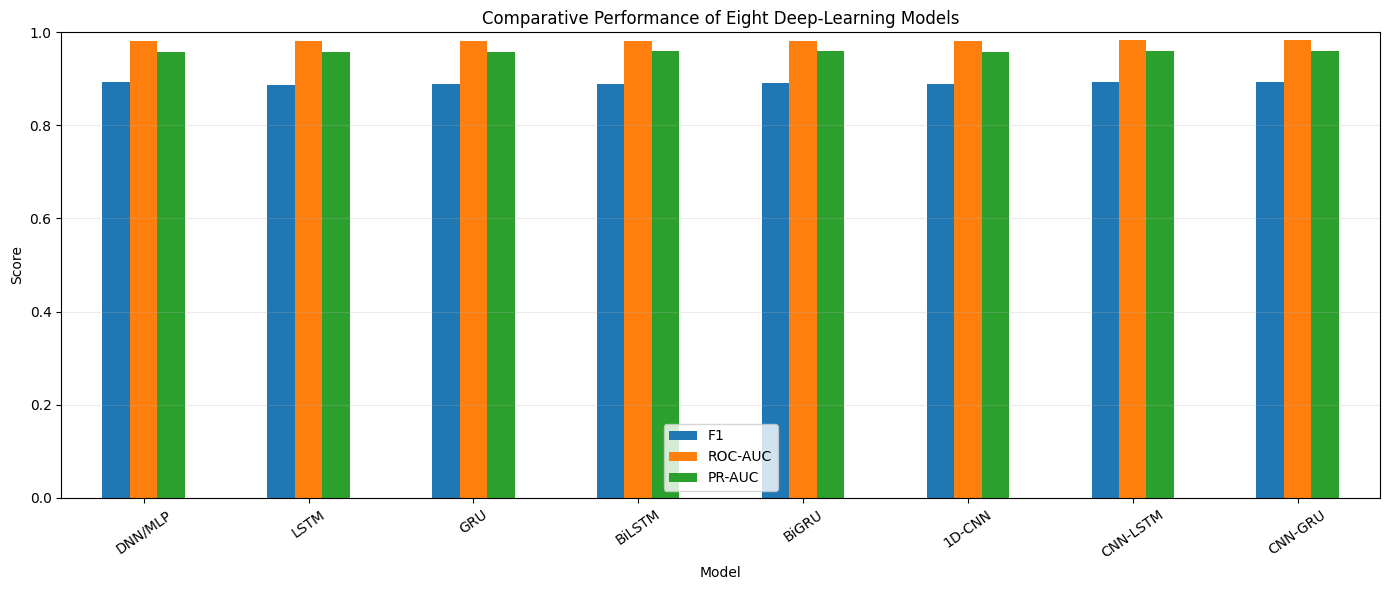

In [ ]:
display(results[["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC","Brier","Parameters","Epochs","Train_time_s"]].round(4))
results.to_csv(f"{OUTPUT_DIR}/table_1_model_comparison.csv")

ax=results[["F1","ROC-AUC","PR-AUC"]].plot(kind="bar",figsize=(14,6))
ax.set_title("Comparative Performance of Eight Deep-Learning Models")
ax.set_ylabel("Score"); ax.set_ylim(0,1); ax.tick_params(axis="x",rotation=35)
ax.grid(axis="y",alpha=.25)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_2_model_performance.png",dpi=300,bbox_inches="tight")
plt.show()

## 10. ROC and Precision–Recall analysis

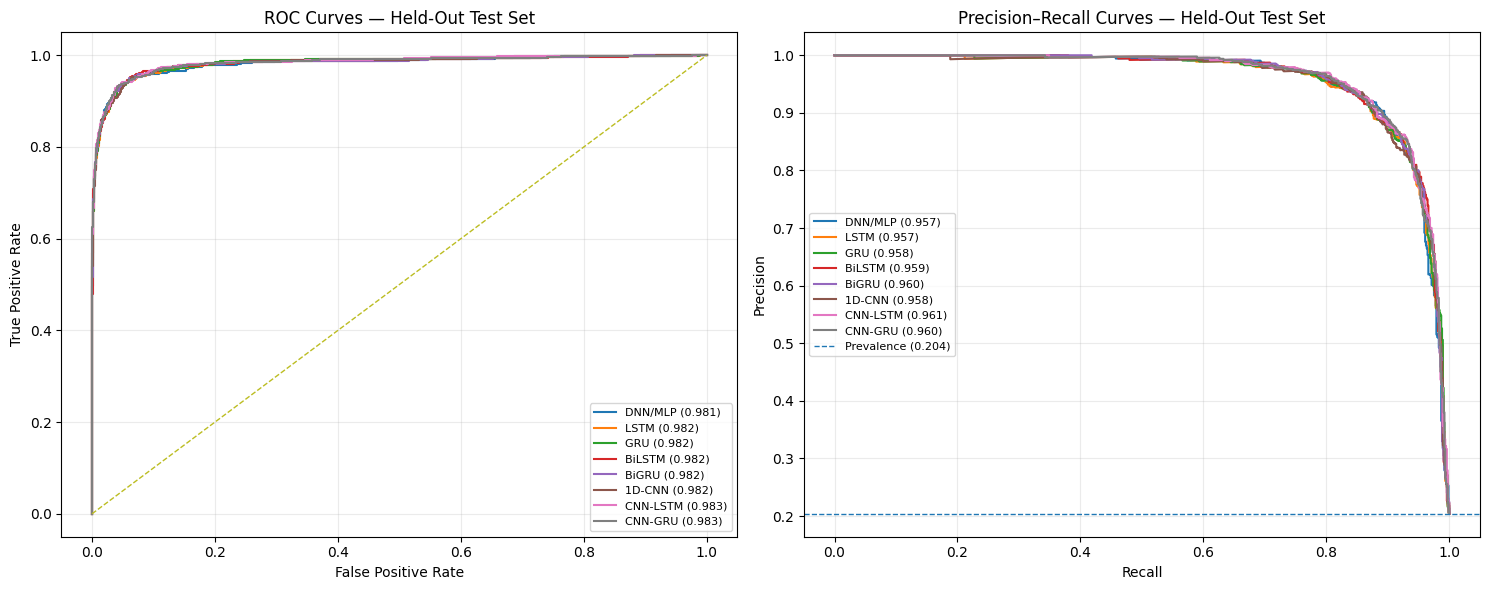

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,6))
for name in MODEL_NAMES:
    p=artifacts[name]["test_prob"]
    fpr,tpr,_=roc_curve(y_test,p)
    axes[0].plot(fpr,tpr,label=f"{name} ({roc_auc_score(y_test,p):.3f})")
    prec,rec,_=precision_recall_curve(y_test,p)
    axes[1].plot(rec,prec,label=f"{name} ({average_precision_score(y_test,p):.3f})")

axes[0].plot([0,1],[0,1],"--",linewidth=1)
axes[0].set_title("ROC Curves — Held-Out Test Set")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[1].axhline(y_test.mean(),linestyle="--",linewidth=1,label=f"Prevalence ({y_test.mean():.3f})")
axes[1].set_title("Precision–Recall Curves — Held-Out Test Set")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
for ax in axes:
    ax.grid(alpha=.25); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_3_roc_pr.png",dpi=300,bbox_inches="tight")
plt.show()

## 11. Selected-model diagnostics

In [ ]:
best_name=results["Val_PR_AUC"].idxmax()
best_prob=artifacts[best_name]["test_prob"]
best_threshold=artifacts[best_name]["threshold"]
best_pred=(best_prob>=best_threshold).astype(int)

print("Selected architecture:",best_name)
print("Selection criterion: validation PR-AUC")
print("Frozen validation threshold:",best_threshold)
print("\nHeld-out test classification report:")
print(classification_report(y_test,best_pred,target_names=["Engaged","Disengaged"],digits=4))

Selected architecture: CNN-GRU
Selection criterion: validation PR-AUC
Frozen validation threshold: 0.48499999999999993

Held-out test classification report:
              precision    recall  f1-score   support

     Engaged     0.9669    0.9789    0.9729      2985
  Disengaged     0.9135    0.8693    0.8908       765

    accuracy                         0.9565      3750
   macro avg     0.9402    0.9241    0.9318      3750
weighted avg     0.9560    0.9565    0.9561      3750



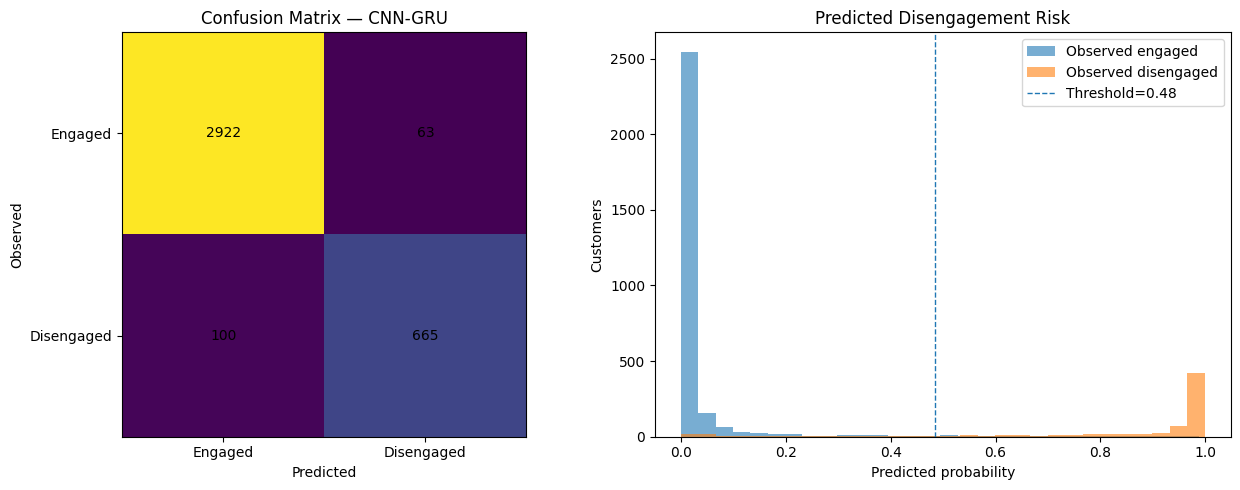

In [ ]:
cm=confusion_matrix(y_test,best_pred)
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].imshow(cm)
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Observed")
axes[0].set_xticks([0,1],["Engaged","Disengaged"]); axes[0].set_yticks([0,1],["Engaged","Disengaged"])
for i in range(2):
    for j in range(2): axes[0].text(j,i,cm[i,j],ha="center",va="center")
axes[1].hist(best_prob[y_test==0],bins=30,alpha=.6,label="Observed engaged")
axes[1].hist(best_prob[y_test==1],bins=30,alpha=.6,label="Observed disengaged")
axes[1].axvline(best_threshold,linestyle="--",linewidth=1,label=f"Threshold={best_threshold:.2f}")
axes[1].set_title("Predicted Disengagement Risk")
axes[1].set_xlabel("Predicted probability"); axes[1].set_ylabel("Customers"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_4_best_model_diagnostics.png",dpi=300,bbox_inches="tight")
plt.show()

## 12. Calibration

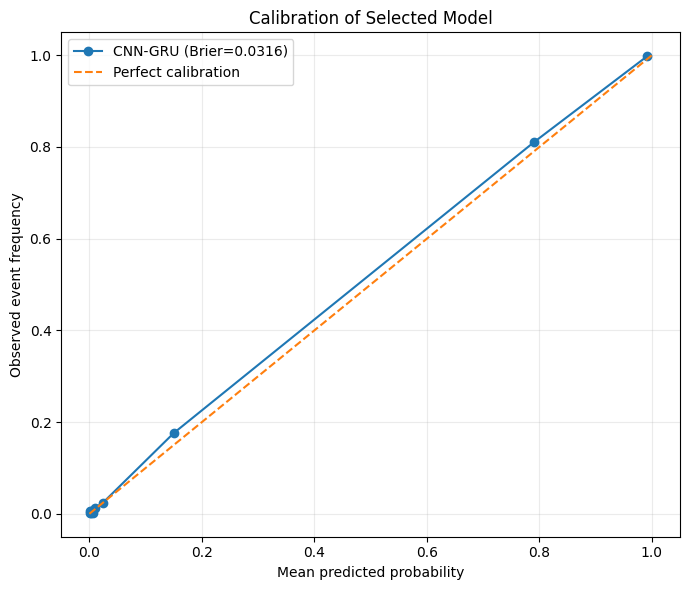

In [ ]:
from sklearn.calibration import calibration_curve
fraction_pos,mean_pred=calibration_curve(y_test,best_prob,n_bins=10,strategy="quantile")
brier=brier_score_loss(y_test,best_prob)
plt.figure(figsize=(7,6))
plt.plot(mean_pred,fraction_pos,marker="o",label=f"{best_name} (Brier={brier:.4f})")
plt.plot([0,1],[0,1],"--",label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed event frequency")
plt.title("Calibration of Selected Model"); plt.grid(alpha=.25); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_5_calibration.png",dpi=300,bbox_inches="tight")
plt.show()

## 13. Bootstrap 95% confidence intervals

In [ ]:
def bootstrap_ci(y_true,prob,threshold,n_boot=1000,seed=42):
    rng=np.random.default_rng(seed); n=len(y_true); rows=[]
    for _ in range(n_boot):
        ii=rng.integers(0,n,n); yt=y_true[ii]; pp=prob[ii]
        if np.unique(yt).size<2: continue
        pred=(pp>=threshold).astype(int)
        rows.append({
            "F1":f1_score(yt,pred,zero_division=0),
            "ROC-AUC":roc_auc_score(yt,pp),
            "PR-AUC":average_precision_score(yt,pp)
        })
    boot=pd.DataFrame(rows)
    est=metric_dict(y_true,prob,threshold)
    out={}
    for col in boot:
        out[col]={"Estimate":est[col],"CI_low":boot[col].quantile(.025),"CI_high":boot[col].quantile(.975)}
    return pd.DataFrame(out).T

bootstrap_results=bootstrap_ci(y_test,best_prob,best_threshold,n_boot=1000,seed=SEED)
display(bootstrap_results.round(4))
bootstrap_results.to_csv(f"{OUTPUT_DIR}/table_2_bootstrap_ci.csv")

,Estimate,CI_low,CI_high
F1,0.8908,0.8740,0.9077
ROC-AUC,0.9826,0.9770,0.9879
PR-AUC,0.9601,0.9508,0.9693


## 14. Classical baselines

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

X_train_comb=np.hstack([X_train_seq.reshape(len(X_train_seq),-1),X_train_static])
X_val_comb=np.hstack([X_val_seq.reshape(len(X_val_seq),-1),X_val_static])
X_test_comb=np.hstack([X_test_seq.reshape(len(X_test_seq),-1),X_test_static])

baseline_rows=[]
lr=LogisticRegression(max_iter=1000,random_state=SEED)
lr.fit(X_train_comb,y_train)
lr_v=lr.predict_proba(X_val_comb)[:,1]; lr_t=lr.predict_proba(X_test_comb)[:,1]
lr_thr=select_threshold(y_val,lr_v)
baseline_rows.append({"Model":"Logistic Regression",**metric_dict(y_test,lr_t,lr_thr)})

hgb=HistGradientBoostingClassifier(max_iter=250,learning_rate=.05,max_leaf_nodes=31,random_state=SEED)
hgb.fit(X_train_comb,y_train)
hgb_v=hgb.predict_proba(X_val_comb)[:,1]; hgb_t=hgb.predict_proba(X_test_comb)[:,1]
hgb_thr=select_threshold(y_val,hgb_v)
baseline_rows.append({"Model":"HistGradientBoosting",**metric_dict(y_test,hgb_t,hgb_thr)})

baseline_results=pd.DataFrame(baseline_rows).set_index("Model")
display(baseline_results.round(4))
baseline_results.to_csv(f"{OUTPUT_DIR}/table_3_classical_baselines.csv")

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold
Model,,,,,,,,
Logistic Regression,0.9589,0.9123,0.8837,0.8977,0.9834,0.9614,0.0308,0.435
HistGradientBoosting,0.9525,0.8601,0.9163,0.8873,0.9836,0.9602,0.0320,0.305


## 15. Ablation study

In [ ]:

def build_single_input_model(kind):
    if kind=="sequence":
        inp=keras.Input(shape=(N_STEPS,N_CHANNELS),name="sequence")
        x=layers.Flatten()(inp) if best_name=="DNN/MLP" else sequence_encoder(best_name,inp)
    elif kind=="static":
        inp=keras.Input(shape=(N_STATIC,),name="static")
        x=static_branch(inp)
    else:
        raise ValueError(kind)
    out=layers.Dense(1,activation="sigmoid")(x)
    return keras.Model(inp,out)

def run_ablation(kind,tx,vx,ex):
    set_seed(SEED); keras.backend.clear_session()
    m=build_single_input_model(kind)
    m.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="pr_auc",curve="PR")])
    m.fit(tx,y_train,validation_data=(vx,y_val),epochs=MAX_EPOCHS,batch_size=BATCH_SIZE,verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_pr_auc",mode="max",patience=PATIENCE,restore_best_weights=True)])
    vp=m.predict(vx,batch_size=BATCH_SIZE,verbose=0).ravel()
    ep=m.predict(ex,batch_size=BATCH_SIZE,verbose=0).ravel()
    thr=select_threshold(y_val,vp)
    return metric_dict(y_test,ep,thr)

ablation_rows=[
    {"Configuration":"Full selected model",**metric_dict(y_test,best_prob,best_threshold)},
    {"Configuration":"Sequence-only",**run_ablation("sequence",X_train_seq,X_val_seq,X_test_seq)},
    {"Configuration":"Static-only",**run_ablation("static",X_train_static,X_val_static,X_test_static)}
]
ablation_results=pd.DataFrame(ablation_rows).set_index("Configuration")
display(ablation_results.round(4))
ablation_results.to_csv(f"{OUTPUT_DIR}/table_4_ablation.csv")

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold
Configuration,,,,,,,,
Full selected model,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316,0.485
Sequence-only,0.9571,0.9092,0.8771,0.8929,0.9816,0.9582,0.0318,0.455
Static-only,0.9544,0.8867,0.8902,0.8885,0.9812,0.9586,0.0327,0.315


## 16. Optional multi-seed robustness

Run this after the main experiment if time permits. It repeats the selected architecture across three seeds; this is much cheaper than retraining all eight architectures three extra times.

In [ ]:
ROBUSTNESS_SEEDS=[42,123,2026]
RUN_ROBUSTNESS=False

def train_selected_seed(seed):
    set_seed(seed); keras.backend.clear_session()
    m=build_model(best_name)
    m.fit(train_inputs,y_train,validation_data=(val_inputs,y_val),epochs=MAX_EPOCHS,batch_size=BATCH_SIZE,verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_pr_auc",mode="max",patience=PATIENCE,restore_best_weights=True)])
    vp=m.predict(val_inputs,batch_size=BATCH_SIZE,verbose=0).ravel()
    tp=m.predict(test_inputs,batch_size=BATCH_SIZE,verbose=0).ravel()
    thr=select_threshold(y_val,vp)
    return {"Seed":seed,"Model":best_name,**metric_dict(y_test,tp,thr)}

if RUN_ROBUSTNESS:
    robustness=pd.DataFrame([train_selected_seed(s) for s in ROBUSTNESS_SEEDS])
    display(robustness.round(4))
    robustness.to_csv(f"{OUTPUT_DIR}/table_5_multiseed_selected_model.csv",index=False)
else:
    print("RUN_ROBUSTNESS=False — skipped for CPU deadline.")

RUN_ROBUSTNESS=False — skipped for CPU deadline.


## 17. Retention optimization / risk stratification

The predicted scores are used to segment test customers by risk. Intervention results are descriptive associations only; they must not be described as causal treatment effects.

In [ ]:
test_customers=df.iloc[test_idx].copy()
test_customers["predicted_risk"]=best_prob
test_customers["risk_tier"]=pd.cut(test_customers["predicted_risk"],
    bins=[0,.25,.50,.75,1],labels=["Low","Moderate","High","Critical"],include_lowest=True)

tier_summary=test_customers.groupby("risk_tier",observed=False).agg(
    Customers=(TARGET,"size"),
    Observed_Disengagement_Rate=(TARGET,"mean"),
    Mean_Risk=("predicted_risk","mean")
)
display(tier_summary.round(4))
tier_summary.to_csv(f"{OUTPUT_DIR}/table_6_risk_tiers.csv")

intervention_summary=test_customers.groupby("retention_intervention").agg(
    Customers=(TARGET,"size"),
    Observed_Disengagement_Rate=(TARGET,"mean"),
    Mean_Predicted_Risk=("predicted_risk","mean")
).sort_values("Mean_Predicted_Risk",ascending=False)
display(intervention_summary.round(4))
intervention_summary.to_csv(f"{OUTPUT_DIR}/table_7_intervention_observational_profile.csv")

,Customers,Observed_Disengagement_Rate,Mean_Risk
risk_tier,,,
Low,2926,0.0198,0.0165
Moderate,104,0.4231,0.3823
High,108,0.6481,0.6237
Critical,612,0.9690,0.9586


,Customers,Observed_Disengagement_Rate,Mean_Predicted_Risk
retention_intervention,,,
Cashback_Offer,562,0.2171,0.2131
Fee_Waiver,570,0.2053,0.2086
Interest_Rate_Boost,543,0.2007,0.1987
No_Intervention,1505,0.2060,0.1910
Personal_Outreach,570,0.1877,0.1897


## 18. Explainability: temporal permutation importance

In [ ]:
rng=np.random.default_rng(SEED)
n_perm=min(2500,len(y_test))
perm_idx=rng.choice(len(y_test),size=n_perm,replace=False)
Xseq_sub=X_test_seq[perm_idx].copy()
Xstat_sub=X_test_static[perm_idx].copy()
y_sub=y_test[perm_idx]

base_prob=artifacts[best_name]["model"].predict(
    {"sequence":Xseq_sub,"static":Xstat_sub},batch_size=BATCH_SIZE,verbose=0).ravel()
base_pr=average_precision_score(y_sub,base_prob)

rows=[]
for ch,label in enumerate(["logins","transactions","avg_balance_log"]):
    drops=[]
    for _ in range(3):
        xp=Xseq_sub.copy()
        order=rng.permutation(n_perm)
        xp[:,:,ch]=xp[order,:,ch]
        pp=artifacts[best_name]["model"].predict(
            {"sequence":xp,"static":Xstat_sub},batch_size=BATCH_SIZE,verbose=0).ravel()
        drops.append(base_pr-average_precision_score(y_sub,pp))
    rows.append({"Feature_Group":f"Temporal:{label}","Mean_PR_AUC_Drop":np.mean(drops)})

temporal_importance=pd.DataFrame(rows).sort_values("Mean_PR_AUC_Drop",ascending=False)
print("Base PR-AUC on explainability subset:",round(base_pr,4))
display(temporal_importance.round(5))
temporal_importance.to_csv(f"{OUTPUT_DIR}/table_8_temporal_importance.csv",index=False)

Base PR-AUC on explainability subset: 0.959


,Feature_Group,Mean_PR_AUC_Drop
0,Temporal:logins,0.00852
1,Temporal:transactions,0.00363
2,Temporal:avg_balance_log,0.00174


## 19. Final publication table and reproducibility manifest

In [ ]:
final_table=results.loc[MODEL_NAMES,["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC","Brier","Parameters","Epochs"]].copy()
final_table.insert(0,"Architecture",final_table.index)
final_table=final_table.reset_index(drop=True)
display(final_table.round(4))
final_table.to_csv(f"{OUTPUT_DIR}/FINAL_TABLE_EIGHT_MODELS.csv",index=False)

manifest={
    "Dataset":DATA_PATH,"Rows":len(df),"Columns":df.shape[1],"Target":TARGET,
    "Target_rate":float(df[TARGET].mean()),"Sequence_shape":str((N_STEPS,N_CHANNELS)),
    "Static_encoded_features":int(N_STATIC),"Train_size":len(y_train),
    "Validation_size":len(y_val),"Test_size":len(y_test),
    "Models":MODEL_NAMES,"Selection_metric":"Validation PR-AUC",
    "Threshold":"Validation F1 maximization","Seed":SEED,
    "Max_epochs":MAX_EPOCHS,"Batch_size":BATCH_SIZE,"Selected_model":best_name
}
pd.Series(manifest,dtype="object").to_json(f"{OUTPUT_DIR}/reproducibility_manifest.json",indent=2)
print("Selected model:",best_name)
print("Outputs:",os.path.abspath(OUTPUT_DIR))

,Architecture,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Parameters,Epochs
0,DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574,0.0320,23233,16
1,LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327,22529,18
2,GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575,0.0326,20177,17
3,BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321,35585,18
4,BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597,0.0319,30881,18
5,1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577,0.0327,26321,15
6,CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,38801,19
7,CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316,34289,19


Selected model: CNN-GRU
Outputs: /content/q1_outputs


## 20. What you can safely claim in the paper

Report the exact observed results from the generated tables. Do not claim “Q1”, “state-of-the-art”, causal intervention effects, production readiness, or broad generalization solely from this notebook.

A defensible methods section should state:
- 25,000 customer records from the supplied synthetic digital-banking dataset.
- Six historical months represented as a 6 × 3 temporal sequence.
- Stratified 70/15/15 train/validation/test partition.
- All scalers/encoders fitted on training data only.
- Eight pre-specified deep-learning architectures.
- Validation PR-AUC used for model selection and validation F1 for threshold selection.
- Test set reserved for final evaluation.
- PR-AUC and ROC-AUC reported because the disengagement class is not balanced.
- Bootstrap confidence intervals and ablation results reported when those cells are completed.
- Retention intervention analysis interpreted as observational unless a randomized or causal identification design is available.

**For a stronger journal submission:** external validation on a real or independently generated dataset is the biggest upgrade beyond making the notebook longer.

In [ ]:
# STEP 1: TEMPORAL STRUCTURE CHECK

print("=" * 90)
print("TEMPORAL STRUCTURE CHECK")
print("=" * 90)

for col in date_time_cols:

    print(f"\nColumn: {col}")
    print("dtype:", df[col].dtype)

    try:
        parsed = pd.to_datetime(
            df[col],
            errors="coerce"
        )

        valid_count = parsed.notna().sum()

        print(
            "Valid datetime values:",
            valid_count,
            "/",
            len(df)
        )

        if valid_count > 0:
            print("Minimum:", parsed.min())
            print("Maximum:", parsed.max())
            print("Unique dates:", parsed.nunique())

    except Exception as e:
        print("Could not parse:", e)

TEMPORAL STRUCTURE CHECK

Column: tenure_months
dtype: int64
Valid datetime values: 25000 / 25000
Minimum: 1970-01-01 00:00:00.000000001
Maximum: 1970-01-01 00:00:00.000000239
Unique dates: 187

Column: bill_pay_mandates
dtype: int64
Valid datetime values: 25000 / 25000
Minimum: 1970-01-01 00:00:00
Maximum: 1970-01-01 00:00:00.000000012
Unique dates: 13


In [ ]:
# STEP 2: TRAIN / VALIDATION / TEST SPLIT INTEGRITY CHECK

print("=" * 90)
print("TRAIN / VALIDATION / TEST SPLIT INTEGRITY CHECK")
print("=" * 90)


required_objects = [
    "train_idx",
    "val_idx",
    "test_idx",
    "y_train",
    "y_val",
    "y_test",
    "X_train_seq",
    "X_val_seq",
    "X_test_seq"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    print("Missing objects:", missing_objects)
    raise NameError(
        "Required split objects are missing. "
        "Run the original data preparation/split cells first."
    )

print("✓ All required split objects are available.")



print("\n" + "-" * 90)
print("SAMPLE COUNTS")
print("-" * 90)

print(f"Total dataset      : {len(df):,}")
print(f"Training samples   : {len(train_idx):,}")
print(f"Validation samples : {len(val_idx):,}")
print(f"Testing samples    : {len(test_idx):,}")

total_split = (
    len(train_idx)
    + len(val_idx)
    + len(test_idx)
)

print(f"Total split        : {total_split:,}")



assert total_split == len(df), (
    "Train + validation + test sizes do not equal dataset size."
)

print("\n✓ All dataset samples are accounted for.")



train_set = set(train_idx)
val_set = set(val_idx)
test_set = set(test_idx)

train_val_overlap = train_set.intersection(val_set)
train_test_overlap = train_set.intersection(test_set)
val_test_overlap = val_set.intersection(test_set)

print("\n" + "-" * 90)
print("INDEX OVERLAP CHECK")
print("-" * 90)

print(
    "Train ↔ Validation:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test:",
    len(val_test_overlap)
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ No sample appears in more than one split.")



print("\n" + "-" * 90)
print("TARGET DISTRIBUTION")
print("-" * 90)

for name, y_split in [
    ("TRAIN", y_train),
    ("VALIDATION", y_val),
    ("TEST", y_test)
]:

    print(f"\n{name}")

    counts = pd.Series(y_split).value_counts().sort_index()

    percentages = (
        pd.Series(y_split)
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print("Counts:")
    print(counts)

    print("Percentage:")
    print(percentages.round(2))



print("\n" + "-" * 90)
print("SEQUENCE DIMENSIONS")
print("-" * 90)

print(
    "X_train_seq:",
    X_train_seq.shape
)

print(
    "X_val_seq  :",
    X_val_seq.shape
)

print(
    "X_test_seq :",
    X_test_seq.shape
)

assert X_train_seq.shape[1:] == (6, 3)
assert X_val_seq.shape[1:] == (6, 3)
assert X_test_seq.shape[1:] == (6, 3)

print("\n✓ All temporal sequences have shape (6, 3).")



assert len(X_train_seq) == len(y_train)
assert len(X_val_seq) == len(y_val)
assert len(X_test_seq) == len(y_test)

print("✓ Sequence and label dimensions match.")



for name, X in [
    ("X_train_seq", X_train_seq),
    ("X_val_seq", X_val_seq),
    ("X_test_seq", X_test_seq)
]:

    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()

    print(
        f"\n{name}: NaN={nan_count}, Inf={inf_count}"
    )

    assert nan_count == 0
    assert inf_count == 0



print("\n" + "=" * 90)
print("✓ SPLIT INTEGRITY CHECK PASSED")
print("=" * 90)

print(
    "\nThe notebook uses a stratified train/validation/test split "
    "with no sample overlap."
)

print(
    "Preprocessing remains train-only as implemented in the notebook."
)

print(
    "\nNOTE: This is a stratified split, not a chronological split."
)

TRAIN / VALIDATION / TEST SPLIT INTEGRITY CHECK
✓ All required split objects are available.

------------------------------------------------------------------------------------------
SAMPLE COUNTS
------------------------------------------------------------------------------------------
Total dataset      : 25,000
Training samples   : 17,500
Validation samples : 3,750
Testing samples    : 3,750
Total split        : 25,000

✓ All dataset samples are accounted for.

------------------------------------------------------------------------------------------
INDEX OVERLAP CHECK
------------------------------------------------------------------------------------------
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0

✓ No sample appears in more than one split.

------------------------------------------------------------------------------------------
TARGET DISTRIBUTION
------------------------------------------------------------------------------------------

TRAIN
Counts:
0    1

In [ ]:
# STEP 3: TEMPORAL SEQUENCE INTEGRITY CHECK

print("=" * 90)
print("STEP 3 — TEMPORAL SEQUENCE INTEGRITY CHECK")
print("=" * 90)


required_sequence_objects = [
    "X_train_seq",
    "X_val_seq",
    "X_test_seq",
    "y_train",
    "y_val",
    "y_test"
]

missing_objects = [
    obj for obj in required_sequence_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        f"Missing required objects: {missing_objects}. "
        "Run the data preparation cells first."
    )

print("✓ All sequence variables are available.")



print("\n" + "-" * 90)
print("SEQUENCE SHAPES")
print("-" * 90)

print(f"X_train_seq : {X_train_seq.shape}")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")

print(f"y_train     : {y_train.shape}")
print(f"y_val       : {y_val.shape}")
print(f"y_test      : {y_test.shape}")



print("\n" + "-" * 90)
print("DIMENSION CHECK")
print("-" * 90)

print("Expected sequence structure:")
print("(samples, 6 months, 3 behavioral features)")

assert X_train_seq.ndim == 3
assert X_val_seq.ndim == 3
assert X_test_seq.ndim == 3

assert X_train_seq.shape[1:] == (6, 3)
assert X_val_seq.shape[1:] == (6, 3)
assert X_test_seq.shape[1:] == (6, 3)

print("✓ Training sequence shape = (samples, 6, 3)")
print("✓ Validation sequence shape = (samples, 6, 3)")
print("✓ Testing sequence shape = (samples, 6, 3)")



print("\n" + "-" * 90)
print("SAMPLE / LABEL ALIGNMENT")
print("-" * 90)

assert len(X_train_seq) == len(y_train)
assert len(X_val_seq) == len(y_val)
assert len(X_test_seq) == len(y_test)

print("✓ Training samples match training labels.")
print("✓ Validation samples match validation labels.")
print("✓ Testing samples match testing labels.")



print("\n" + "-" * 90)
print("NaN CHECK")
print("-" * 90)

for name, X in [
    ("X_train_seq", X_train_seq),
    ("X_val_seq", X_val_seq),
    ("X_test_seq", X_test_seq)
]:

    nan_count = np.isnan(X).sum()

    print(
        f"{name}: {nan_count:,} NaN values"
    )

    assert nan_count == 0



print("\n" + "-" * 90)
print("INFINITE VALUE CHECK")
print("-" * 90)

for name, X in [
    ("X_train_seq", X_train_seq),
    ("X_val_seq", X_val_seq),
    ("X_test_seq", X_test_seq)
]:

    inf_count = np.isinf(X).sum()

    print(
        f"{name}: {inf_count:,} infinite values"
    )

    assert inf_count == 0



print("\n" + "-" * 90)
print("TARGET LABEL CHECK")
print("-" * 90)

for name, y_split in [
    ("Training", y_train),
    ("Validation", y_val),
    ("Testing", y_test)
]:

    unique_values = np.unique(y_split)

    print(
        f"{name} target values: {unique_values}"
    )

    assert set(unique_values).issubset({0, 1})

print("✓ Target contains only binary values: 0 and 1.")



print("\n" + "-" * 90)
print("CLASS DISTRIBUTION")
print("-" * 90)

for name, y_split in [
    ("Training", y_train),
    ("Validation", y_val),
    ("Testing", y_test)
]:

    positive_rate = np.mean(y_split)

    print(
        f"{name:<12}: "
        f"Disengaged={positive_rate:.4f} "
        f"({positive_rate*100:.2f}%)"
    )



print("\n" + "-" * 90)
print("SEQUENCE VALUE RANGE")
print("-" * 90)

for name, X in [
    ("Train", X_train_seq),
    ("Validation", X_val_seq),
    ("Test", X_test_seq)
]:

    print(
        f"{name:<12}: "
        f"Min={X.min():.4f}, "
        f"Max={X.max():.4f}, "
        f"Mean={X.mean():.4f}, "
        f"Std={X.std():.4f}"
    )



print("\n" + "=" * 90)
print("✓ STEP 3 PASSED — TEMPORAL SEQUENCE INTEGRITY VERIFIED")
print("=" * 90)

print("\nYour temporal input is ready for the 8 deep-learning models.")

STEP 3 — TEMPORAL SEQUENCE INTEGRITY CHECK
✓ All sequence variables are available.

------------------------------------------------------------------------------------------
SEQUENCE SHAPES
------------------------------------------------------------------------------------------
X_train_seq : (17500, 6, 3)
X_val_seq   : (3750, 6, 3)
X_test_seq  : (3750, 6, 3)
y_train     : (17500,)
y_val       : (3750,)
y_test      : (3750,)

------------------------------------------------------------------------------------------
DIMENSION CHECK
------------------------------------------------------------------------------------------
Expected sequence structure:
(samples, 6 months, 3 behavioral features)
✓ Training sequence shape = (samples, 6, 3)
✓ Validation sequence shape = (samples, 6, 3)
✓ Testing sequence shape = (samples, 6, 3)

------------------------------------------------------------------------------------------
SAMPLE / LABEL ALIGNMENT
------------------------------------------------

In [ ]:
# STEP 4 — TRAIN AND EVALUATE ALL 8 DEEP-LEARNING MODELS

print("=" * 90)
print("STEP 4 — TRAINING ALL 8 DEEP-LEARNING MODELS")
print("=" * 90)


runs = []
artifacts = {}


for model_name in MODEL_NAMES:

    print("\n")
    print("=" * 90)
    print(f"TRAINING MODEL: {model_name}")
    print("=" * 90)

    set_seed(SEED)

    keras.backend.clear_session()

    model = build_model(model_name)

    print(f"\nParameters: {model.count_params():,}")


    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]


    start_time = time.perf_counter()

    history = model.fit(
        train_inputs,
        y_train,

        validation_data=(
            val_inputs,
            y_val
        ),

        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,

        shuffle=True,
        verbose=1,

        callbacks=callbacks
    )

    training_time = (
        time.perf_counter() - start_time
    )


    val_prob = model.predict(
        val_inputs,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()


    test_prob = model.predict(
        test_inputs,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()


    best_threshold = select_threshold(
        y_val,
        val_prob
    )


    validation_metrics = metric_dict(
        y_val,
        val_prob,
        best_threshold
    )


    test_metrics = metric_dict(
        y_test,
        test_prob,
        best_threshold
    )


    runs.append({

        "Model": model_name,

        "Accuracy":
            test_metrics["Accuracy"],

        "Precision":
            test_metrics["Precision"],

        "Recall":
            test_metrics["Recall"],

        "F1 Score":
            test_metrics["F1"],

        "ROC-AUC":
            test_metrics["ROC-AUC"],

        "PR-AUC":
            test_metrics["PR-AUC"],

        "Brier":
            test_metrics["Brier"],

        "Threshold":
            best_threshold,

        "Validation_F1":
            validation_metrics["F1"],

        "Validation_PR-AUC":
            validation_metrics["PR-AUC"],

        "Parameters":
            model.count_params(),

        "Epochs":
            len(history.history["loss"]),

        "Train_time_s":
            training_time
    })


    artifacts[model_name] = {

        "model": model,

        "history":
            history.history,

        "val_prob":
            val_prob,

        "test_prob":
            test_prob,

        "threshold":
            best_threshold
    }


    print("\n" + "-" * 70)

    print(
        f"Model             : {model_name}"
    )

    print(
        f"Epochs            : "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Training time     : "
        f"{training_time:.2f} seconds"
    )

    print(
        f"Validation PR-AUC : "
        f"{validation_metrics['PR-AUC']:.4f}"
    )

    print(
        f"Selected threshold : "
        f"{best_threshold:.2f}"
    )

    print(
        f"Test Accuracy     : "
        f"{test_metrics['Accuracy']:.4f}"
    )

    print(
        f"Test Precision    : "
        f"{test_metrics['Precision']:.4f}"
    )

    print(
        f"Test Recall       : "
        f"{test_metrics['Recall']:.4f}"
    )

    print(
        f"Test F1 Score     : "
        f"{test_metrics['F1']:.4f}"
    )

    print(
        f"Test ROC-AUC      : "
        f"{test_metrics['ROC-AUC']:.4f}"
    )

    print(
        f"Test PR-AUC       : "
        f"{test_metrics['PR-AUC']:.4f}"
    )


results = pd.DataFrame(runs)

results["Model"] = pd.Categorical(
    results["Model"],
    categories=MODEL_NAMES,
    ordered=True
)

results = (
    results
    .sort_values("Model")
    .reset_index(drop=True)
)


print("\n\n")
print("=" * 110)
print("COMPLETE 8-MODEL PERFORMANCE RESULTS")
print("=" * 110)

display(
    results.round(4)
)


os.makedirs(OUTPUT_DIR, exist_ok=True)

results.to_csv(
    f"{OUTPUT_DIR}/eight_model_complete_results.csv",
    index=False
)

print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/eight_model_complete_results.csv"
)

print("\n" + "=" * 90)
print("✓ STEP 4 COMPLETED")
print("=" * 90)

STEP 4 — TRAINING ALL 8 DEEP-LEARNING MODELS


TRAINING MODEL: DNN/MLP

Parameters: 23,233
Epoch 1/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2330 - pr_auc: 0.8702 - roc_auc: 0.9493 - val_loss: 0.1716 - val_pr_auc: 0.9527 - val_roc_auc: 0.9844 - learning_rate: 0.0010
Epoch 2/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1351 - pr_auc: 0.9421 - roc_auc: 0.9767 - val_loss: 0.1396 - val_pr_auc: 0.9567 - val_roc_auc: 0.9859 - learning_rate: 0.0010
Epoch 3/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1264 - pr_auc: 0.9493 - roc_auc: 0.9797 - val_loss: 0.1227 - val_pr_auc: 0.9578 - val_roc_auc: 0.9861 - learning_rate: 0.0010
Epoch 4/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1203 - pr_auc: 0.9535 - roc_auc: 0.9823 - val_loss: 0.1165 - val_pr_auc: 0.9586 - val_roc_auc: 0.9860 - learning_rate: 0.0010
Epoch 5/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1158 - pr_auc: 0.9573 - roc_auc: 0.9830 - val_loss: 0.1150 - val_pr_auc: 0.9580 - val_roc_auc: 0.9856 -

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier,Threshold,Validation_F1,Validation_PR-AUC,Parameters,Epochs,Train_time_s
0,DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574,0.0320,0.385,0.8913,0.9589,23233,16,12.5845
1,LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327,0.290,0.8885,0.9569,22529,18,24.2589
2,GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575,0.0326,0.390,0.8912,0.9579,20177,17,25.7082
3,BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321,0.380,0.8929,0.9576,35585,18,39.1539
4,BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597,0.0319,0.375,0.8934,0.9583,30881,18,41.9088
5,1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577,0.0327,0.410,0.8899,0.9582,26321,15,20.3306
6,CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,0.395,0.8899,0.9593,38801,19,47.9705
7,CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316,0.485,0.8880,0.9596,34289,19,43.3732



✓ Saved: q1_outputs/eight_model_complete_results.csv

✓ STEP 4 COMPLETED


In [ ]:
# STEP 5 — FINAL 8-MODEL COMPARISON TABLE

comparison_df = results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
].copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

comparison_df[metric_columns] = (
    comparison_df[metric_columns]
    .astype(float)
    .round(4)
)

print("=" * 100)
print("COMPLETE PERFORMANCE TABLE INCLUDING PR-AUC")
print("=" * 100)

display(comparison_df)

comparison_df.to_csv(
    f"{OUTPUT_DIR}/table_1_performance_comparison.csv",
    index=False
)

print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/table_1_performance_comparison.csv"
)

COMPLETE PERFORMANCE TABLE INCLUDING PR-AUC


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574
1,LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568
2,GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575
3,BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591
4,BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597
5,1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577
6,CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606
7,CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601



✓ Saved: q1_outputs/table_1_performance_comparison.csv


In [ ]:
# STEP 6 — MULTI-SEED ROBUSTNESS ANALYSIS

RUN_ROBUSTNESS = True

ROBUSTNESS_SEEDS = [42, 52, 62]

robustness_results = []

print("=" * 100)
print("STEP 6 — MULTI-SEED ROBUSTNESS ANALYSIS")
print("=" * 100)

for seed_value in ROBUSTNESS_SEEDS:

    print("\n" + "=" * 80)
    print(f"RUNNING SEED: {seed_value}")
    print("=" * 80)

    set_seed(seed_value)

    for model_name in MODEL_NAMES:

        print(f"\nModel: {model_name}")

        keras.backend.clear_session()

        set_seed(seed_value)

        model = build_model(model_name)

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_pr_auc",
                mode="max",
                patience=PATIENCE,
                restore_best_weights=True,
                verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_pr_auc",
                mode="max",
                factor=0.5,
                patience=3,
                min_lr=1e-5,
                verbose=0
            )
        ]

        model.fit(
            train_inputs,
            y_train,
            validation_data=(val_inputs, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            verbose=0,
            callbacks=callbacks
        )

        val_prob = model.predict(
            val_inputs,
            batch_size=BATCH_SIZE,
            verbose=0
        ).ravel()

        test_prob = model.predict(
            test_inputs,
            batch_size=BATCH_SIZE,
            verbose=0
        ).ravel()

        threshold = select_threshold(
            y_val,
            val_prob
        )

        metrics = metric_dict(
            y_test,
            test_prob,
            threshold
        )

        robustness_results.append({

            "Seed": seed_value,
            "Model": model_name,

            "Accuracy":
                metrics["Accuracy"],

            "Precision":
                metrics["Precision"],

            "Recall":
                metrics["Recall"],

            "F1 Score":
                metrics["F1"],

            "ROC-AUC":
                metrics["ROC-AUC"],

            "PR-AUC":
                metrics["PR-AUC"],

            "Brier":
                metrics["Brier"]
        })

        print(
            f"ROC-AUC={metrics['ROC-AUC']:.4f} | "
            f"PR-AUC={metrics['PR-AUC']:.4f} | "
            f"F1={metrics['F1']:.4f}"
        )



robustness_df = pd.DataFrame(
    robustness_results
)

print("\n" + "=" * 100)
print("MULTI-SEED RESULTS")
print("=" * 100)

display(
    robustness_df.round(4)
)



robustness_summary = (
    robustness_df
    .groupby("Model")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC",
            "Brier"
        ]
    ]
    .agg(["mean", "std"])
)

print("\n" + "=" * 100)
print("ROBUSTNESS SUMMARY — MEAN ± STANDARD DEVIATION")
print("=" * 100)

display(
    robustness_summary.round(4)
)



robustness_df.to_csv(
    f"{OUTPUT_DIR}/multi_seed_results.csv",
    index=False
)

robustness_summary.to_csv(
    f"{OUTPUT_DIR}/multi_seed_summary.csv"
)

print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/multi_seed_results.csv"
)

print(
    f"✓ Saved: "
    f"{OUTPUT_DIR}/multi_seed_summary.csv"
)

print("\n✓ STEP 6 COMPLETED")

STEP 6 — MULTI-SEED ROBUSTNESS ANALYSIS

RUNNING SEED: 42

Model: DNN/MLP
ROC-AUC=0.9810 | PR-AUC=0.9574 | F1=0.8929

Model: LSTM
ROC-AUC=0.9818 | PR-AUC=0.9568 | F1=0.8865

Model: GRU
ROC-AUC=0.9824 | PR-AUC=0.9575 | F1=0.8876

Model: BiLSTM
ROC-AUC=0.9819 | PR-AUC=0.9591 | F1=0.8885

Model: BiGRU
ROC-AUC=0.9821 | PR-AUC=0.9597 | F1=0.8915

Model: 1D-CNN
ROC-AUC=0.9822 | PR-AUC=0.9577 | F1=0.8896

Model: CNN-LSTM
ROC-AUC=0.9833 | PR-AUC=0.9606 | F1=0.8903

Model: CNN-GRU
ROC-AUC=0.9826 | PR-AUC=0.9601 | F1=0.8908

RUNNING SEED: 52

Model: DNN/MLP
ROC-AUC=0.9833 | PR-AUC=0.9596 | F1=0.8893

Model: LSTM
ROC-AUC=0.9827 | PR-AUC=0.9589 | F1=0.8883

Model: GRU
ROC-AUC=0.9827 | PR-AUC=0.9593 | F1=0.8902

Model: BiLSTM
ROC-AUC=0.9817 | PR-AUC=0.9584 | F1=0.8912

Model: BiGRU
ROC-AUC=0.9821 | PR-AUC=0.9590 | F1=0.8931

Model: 1D-CNN
ROC-AUC=0.9832 | PR-AUC=0.9581 | F1=0.8901

Model: CNN-LSTM
ROC-AUC=0.9831 | PR-AUC=0.9607 | F1=0.8902

Model: CNN-GRU
ROC-AUC=0.9836 | PR-AUC=0.9607 | F1=0.9006


,Seed,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier
0,42,DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574,0.0320
1,42,LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327
2,42,GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575,0.0326
3,42,BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321
4,42,BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597,0.0319
5,42,1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577,0.0327
6,42,CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314
7,42,CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316
8,52,DNN/MLP,0.9560,0.9132,0.8667,0.8893,0.9833,0.9596,0.0322
9,52,LSTM,0.9549,0.8984,0.8784,0.8883,0.9827,0.9589,0.0318



ROBUSTNESS SUMMARY — MEAN ± STANDARD DEVIATION


Accuracy         Precision          Recall         F1 Score          \
             mean     std      mean     std    mean     std     mean     std   
Model                                                                          
1D-CNN     0.9551  0.0006    0.8883  0.0172  0.8928  0.0193   0.8903  0.0008   
BiGRU      0.9564  0.0009    0.9016  0.0228  0.8832  0.0223   0.8920  0.0010   
BiLSTM     0.9553  0.0008    0.8965  0.0155  0.8832  0.0156   0.8896  0.0014   
CNN-GRU    0.9573  0.0026    0.9064  0.0178  0.8824  0.0131   0.8941  0.0057   
CNN-LSTM   0.9553  0.0004    0.8875  0.0022  0.8941  0.0023   0.8908  0.0010   
DNN/MLP    0.9557  0.0005    0.9009  0.0134  0.8802  0.0171   0.8902  0.0024   
GRU        0.9552  0.0009    0.8961  0.0074  0.8828  0.0042   0.8894  0.0016   
LSTM       0.9534  0.0015    0.8767  0.0211  0.8989  0.0203   0.8873  0.0009   

         ROC-AUC          PR-AUC           Brier          
            mean     std    mean     std    mean     std  
Model                                                     
1D-CNN    0.9831  0.0008  0.9587  0.0014  0.0319  0.0007  
BiGRU     0.9822  0.0002  0.9590  0.0007  0.0321  0.0005  
BiLSTM    0.9820  0.0002  0.9583  0.0009  0.0323  0.0006  
CNN-GRU   0.9825  0.0011  0.9596  0.0013  0.0314  0.0005  
CNN-LSTM  0.9827  0.0009  0.9599  0.0013  0.0315  0.0005  
DNN/MLP   0.9819  0.0012  0.9582  0.0012  0.0323  0.0004  
GRU       0.9827  0.0003  0.9587  0.0010  0.0322  0.0004  
LSTM      0.9823  0.0005  0.9581  0.0012  0.0323  0.0004


✓ Saved: q1_outputs/multi_seed_results.csv
✓ Saved: q1_outputs/multi_seed_summary.csv

✓ STEP 6 COMPLETED


In [ ]:
# STEP 7 — BOOTSTRAP 95% CONFIDENCE INTERVALS

print("=" * 100)
print("STEP 7 — BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 100)


def bootstrap_metric_ci(
    y_true,
    probabilities,
    threshold,
    n_boot=2000,
    seed=42
):
    """
    Calculate bootstrap 95% confidence intervals for:
    Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC.
    """

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    rng = np.random.default_rng(seed)

    n = len(y_true)

    bootstrap_rows = []

    for _ in range(n_boot):

        indices = rng.integers(
            low=0,
            high=n,
            size=n
        )

        y_boot = y_true[indices]
        p_boot = probabilities[indices]

        if np.unique(y_boot).size < 2:
            continue

        pred_boot = (
            p_boot >= threshold
        ).astype(int)

        bootstrap_rows.append({

            "Accuracy":
                accuracy_score(
                    y_boot,
                    pred_boot
                ),

            "Precision":
                precision_score(
                    y_boot,
                    pred_boot,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_boot,
                    pred_boot,
                    zero_division=0
                ),

            "F1 Score":
                f1_score(
                    y_boot,
                    pred_boot,
                    zero_division=0
                ),

            "ROC-AUC":
                roc_auc_score(
                    y_boot,
                    p_boot
                ),

            "PR-AUC":
                average_precision_score(
                    y_boot,
                    p_boot
                )
        })

    bootstrap_df = pd.DataFrame(
        bootstrap_rows
    )


    point_predictions = (
        probabilities >= threshold
    ).astype(int)

    point_estimates = {

        "Accuracy":
            accuracy_score(
                y_true,
                point_predictions
            ),

        "Precision":
            precision_score(
                y_true,
                point_predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                point_predictions,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_true,
                point_predictions,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                probabilities
            )
    }


    output = []

    for metric in point_estimates:

        output.append({

            "Metric":
                metric,

            "Estimate":
                point_estimates[metric],

            "CI Lower":
                bootstrap_df[metric].quantile(
                    0.025
                ),

            "CI Upper":
                bootstrap_df[metric].quantile(
                    0.975
                )
        })

    return pd.DataFrame(output)



all_bootstrap_results = []

for model_name in MODEL_NAMES:

    print(
        f"\nBootstrapping: {model_name}"
    )

    test_prob = artifacts[
        model_name
    ]["test_prob"]

    threshold = artifacts[
        model_name
    ]["threshold"]

    ci_df = bootstrap_metric_ci(
        y_true=y_test,
        probabilities=test_prob,
        threshold=threshold,
        n_boot=2000,
        seed=SEED
    )

    ci_df.insert(
        0,
        "Model",
        model_name
    )

    all_bootstrap_results.append(
        ci_df
    )

    print(
        ci_df.round(4).to_string(
            index=False
        )
    )



bootstrap_all_df = pd.concat(
    all_bootstrap_results,
    ignore_index=True
)



print("\n" + "=" * 100)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS — ALL 8 MODELS")
print("=" * 100)

display(
    bootstrap_all_df.round(4)
)



bootstrap_publication = (
    bootstrap_all_df
    .copy()
)

bootstrap_publication["95% CI"] = (
    bootstrap_publication["CI Lower"].map(
        lambda x: f"{x:.4f}"
    )
    + " – "
    +
    bootstrap_publication["CI Upper"].map(
        lambda x: f"{x:.4f}"
    )
)

bootstrap_publication = (
    bootstrap_publication[
        [
            "Model",
            "Metric",
            "Estimate",
            "95% CI"
        ]
    ]
)


print("\n" + "=" * 100)
print("PUBLICATION-READY BOOTSTRAP TABLE")
print("=" * 100)

display(
    bootstrap_publication
)



bootstrap_all_df.to_csv(
    f"{OUTPUT_DIR}/table_2_bootstrap_all_models.csv",
    index=False
)

bootstrap_publication.to_csv(
    f"{OUTPUT_DIR}/table_2_bootstrap_publication.csv",
    index=False
)

print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/table_2_bootstrap_all_models.csv"
)

print(
    f"✓ Saved: "
    f"{OUTPUT_DIR}/table_2_bootstrap_publication.csv"
)

print("\n" + "=" * 100)
print("✓ STEP 7 COMPLETED")
print("=" * 100)

STEP 7 — BOOTSTRAP 95% CONFIDENCE INTERVALS

Bootstrapping: DNN/MLP
  Model    Metric  Estimate  CI Lower  CI Upper
DNN/MLP  Accuracy    0.9560    0.9493    0.9627
DNN/MLP Precision    0.8866    0.8630    0.9090
DNN/MLP    Recall    0.8993    0.8779    0.9191
DNN/MLP  F1 Score    0.8929    0.8762    0.9090
DNN/MLP   ROC-AUC    0.9810    0.9745    0.9865
DNN/MLP    PR-AUC    0.9574    0.9471    0.9672

Bootstrapping: LSTM
Model    Metric  Estimate  CI Lower  CI Upper
 LSTM  Accuracy    0.9520    0.9453    0.9587
 LSTM Precision    0.8563    0.8324    0.8797
 LSTM    Recall    0.9190    0.8999    0.9377
 LSTM  F1 Score    0.8865    0.8704    0.9029
 LSTM   ROC-AUC    0.9818    0.9757    0.9871
 LSTM    PR-AUC    0.9568    0.9466    0.9665

Bootstrapping: GRU
Model    Metric  Estimate  CI Lower  CI Upper
  GRU  Accuracy    0.9541    0.9477    0.9605
  GRU Precision    0.8876    0.8642    0.9106
  GRU    Recall    0.8876    0.8658    0.9087
  GRU  F1 Score    0.8876    0.8711    0.9034
  G

,Model,Metric,Estimate,CI Lower,CI Upper
0,DNN/MLP,Accuracy,0.9560,0.9493,0.9627
1,DNN/MLP,Precision,0.8866,0.8630,0.9090
2,DNN/MLP,Recall,0.8993,0.8779,0.9191
3,DNN/MLP,F1 Score,0.8929,0.8762,0.9090
4,DNN/MLP,ROC-AUC,0.9810,0.9745,0.9865
5,DNN/MLP,PR-AUC,0.9574,0.9471,0.9672
6,LSTM,Accuracy,0.9520,0.9453,0.9587
7,LSTM,Precision,0.8563,0.8324,0.8797
8,LSTM,Recall,0.9190,0.8999,0.9377
9,LSTM,F1 Score,0.8865,0.8704,0.9029



PUBLICATION-READY BOOTSTRAP TABLE


,Model,Metric,Estimate,95% CI
0,DNN/MLP,Accuracy,0.956000,0.9493 – 0.9627
1,DNN/MLP,Precision,0.886598,0.8630 – 0.9090
2,DNN/MLP,Recall,0.899346,0.8779 – 0.9191
3,DNN/MLP,F1 Score,0.892927,0.8762 – 0.9090
4,DNN/MLP,ROC-AUC,0.980967,0.9745 – 0.9865
5,DNN/MLP,PR-AUC,0.957380,0.9471 – 0.9672
6,LSTM,Accuracy,0.952000,0.9453 – 0.9587
7,LSTM,Precision,0.856273,0.8324 – 0.8797
8,LSTM,Recall,0.918954,0.8999 – 0.9377
9,LSTM,F1 Score,0.886507,0.8704 – 0.9029



✓ Saved: q1_outputs/table_2_bootstrap_all_models.csv
✓ Saved: q1_outputs/table_2_bootstrap_publication.csv

✓ STEP 7 COMPLETED


In [ ]:
# STEP 8 — CLASSICAL MACHINE-LEARNING BASELINES

print("=" * 100)
print("STEP 8 — CLASSICAL MACHINE-LEARNING BASELINES")
print("=" * 100)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier
)


X_train_comb = np.hstack([
    X_train_seq.reshape(len(X_train_seq), -1),
    X_train_static
])

X_val_comb = np.hstack([
    X_val_seq.reshape(len(X_val_seq), -1),
    X_val_static
])

X_test_comb = np.hstack([
    X_test_seq.reshape(len(X_test_seq), -1),
    X_test_static
])

print("\nCombined feature dimensions:")
print("Train:", X_train_comb.shape)
print("Validation:", X_val_comb.shape)
print("Test:", X_test_comb.shape)



baseline_rows = []
baseline_models = {}



print("\n" + "-" * 90)
print("1. LOGISTIC REGRESSION")
print("-" * 90)

set_seed(SEED)

lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced"
)

start = time.perf_counter()

lr.fit(
    X_train_comb,
    y_train
)

lr_time = time.perf_counter() - start

lr_val_prob = lr.predict_proba(
    X_val_comb
)[:, 1]

lr_test_prob = lr.predict_proba(
    X_test_comb
)[:, 1]

lr_threshold = select_threshold(
    y_val,
    lr_val_prob
)

lr_metrics = metric_dict(
    y_test,
    lr_test_prob,
    lr_threshold
)

baseline_rows.append({
    "Model": "Logistic Regression",
    **lr_metrics,
    "Threshold": lr_threshold,
    "Parameters": lr.coef_.size + lr.intercept_.size,
    "Train_time_s": lr_time
})

baseline_models["Logistic Regression"] = {
    "model": lr,
    "val_prob": lr_val_prob,
    "test_prob": lr_test_prob,
    "threshold": lr_threshold
}

print(
    f"Accuracy : {lr_metrics['Accuracy']:.4f}"
)

print(
    f"Precision: {lr_metrics['Precision']:.4f}"
)

print(
    f"Recall   : {lr_metrics['Recall']:.4f}"
)

print(
    f"F1       : {lr_metrics['F1']:.4f}"
)

print(
    f"ROC-AUC  : {lr_metrics['ROC-AUC']:.4f}"
)

print(
    f"PR-AUC   : {lr_metrics['PR-AUC']:.4f}"
)



print("\n" + "-" * 90)
print("2. HISTOGRAM-BASED GRADIENT BOOSTING")
print("-" * 90)

set_seed(SEED)

hgb = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=SEED
)

start = time.perf_counter()

hgb.fit(
    X_train_comb,
    y_train
)

hgb_time = time.perf_counter() - start

hgb_val_prob = hgb.predict_proba(
    X_val_comb
)[:, 1]

hgb_test_prob = hgb.predict_proba(
    X_test_comb
)[:, 1]

hgb_threshold = select_threshold(
    y_val,
    hgb_val_prob
)

hgb_metrics = metric_dict(
    y_test,
    hgb_test_prob,
    hgb_threshold
)

baseline_rows.append({
    "Model": "HistGradientBoosting",
    **hgb_metrics,
    "Threshold": hgb_threshold,
    "Parameters": np.nan,
    "Train_time_s": hgb_time
})

baseline_models["HistGradientBoosting"] = {
    "model": hgb,
    "val_prob": hgb_val_prob,
    "test_prob": hgb_test_prob,
    "threshold": hgb_threshold
}

print(
    f"Accuracy : {hgb_metrics['Accuracy']:.4f}"
)

print(
    f"Precision: {hgb_metrics['Precision']:.4f}"
)

print(
    f"Recall   : {hgb_metrics['Recall']:.4f}"
)

print(
    f"F1       : {hgb_metrics['F1']:.4f}"
)

print(
    f"ROC-AUC  : {hgb_metrics['ROC-AUC']:.4f}"
)

print(
    f"PR-AUC   : {hgb_metrics['PR-AUC']:.4f}"
)



print("\n" + "-" * 90)
print("3. RANDOM FOREST")
print("-" * 90)

set_seed(SEED)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

start = time.perf_counter()

rf.fit(
    X_train_comb,
    y_train
)

rf_time = time.perf_counter() - start

rf_val_prob = rf.predict_proba(
    X_val_comb
)[:, 1]

rf_test_prob = rf.predict_proba(
    X_test_comb
)[:, 1]

rf_threshold = select_threshold(
    y_val,
    rf_val_prob
)

rf_metrics = metric_dict(
    y_test,
    rf_test_prob,
    rf_threshold
)

baseline_rows.append({
    "Model": "Random Forest",
    **rf_metrics,
    "Threshold": rf_threshold,
    "Parameters": np.nan,
    "Train_time_s": rf_time
})

baseline_models["Random Forest"] = {
    "model": rf,
    "val_prob": rf_val_prob,
    "test_prob": rf_test_prob,
    "threshold": rf_threshold
}

print(
    f"Accuracy : {rf_metrics['Accuracy']:.4f}"
)

print(
    f"Precision: {rf_metrics['Precision']:.4f}"
)

print(
    f"Recall   : {rf_metrics['Recall']:.4f}"
)

print(
    f"F1       : {rf_metrics['F1']:.4f}"
)

print(
    f"ROC-AUC  : {rf_metrics['ROC-AUC']:.4f}"
)

print(
    f"PR-AUC   : {rf_metrics['PR-AUC']:.4f}"
)



baseline_results = pd.DataFrame(
    baseline_rows
)

print("\n" + "=" * 100)
print("CLASSICAL MACHINE-LEARNING BASELINE RESULTS")
print("=" * 100)

display(
    baseline_results.round(4)
)



baseline_results.to_csv(
    f"{OUTPUT_DIR}/classical_ml_baseline_results.csv",
    index=False
)

print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/classical_ml_baseline_results.csv"
)

print("\n" + "=" * 100)
print("✓ STEP 8 COMPLETED")
print("=" * 100)

STEP 8 — CLASSICAL MACHINE-LEARNING BASELINES

Combined feature dimensions:
Train: (17500, 63)
Validation: (3750, 63)
Test: (3750, 63)

------------------------------------------------------------------------------------------
1. LOGISTIC REGRESSION
------------------------------------------------------------------------------------------
Accuracy : 0.9584
Precision: 0.9076
Recall   : 0.8863
F1       : 0.8968
ROC-AUC  : 0.9833
PR-AUC   : 0.9606

------------------------------------------------------------------------------------------
2. HISTOGRAM-BASED GRADIENT BOOSTING
------------------------------------------------------------------------------------------
Accuracy : 0.9525
Precision: 0.8601
Recall   : 0.9163
F1       : 0.8873
ROC-AUC  : 0.9836
PR-AUC   : 0.9602

------------------------------------------------------------------------------------------
3. RANDOM FOREST
------------------------------------------------------------------------------------------
Accuracy : 0.9563
Preci

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold,Parameters,Train_time_s
0,Logistic Regression,0.9584,0.9076,0.8863,0.8968,0.9833,0.9606,0.0381,0.740,64.0,0.3793
1,HistGradientBoosting,0.9525,0.8601,0.9163,0.8873,0.9836,0.9602,0.0320,0.305,NaN,1.3956
2,Random Forest,0.9563,0.9023,0.8810,0.8915,0.9833,0.9588,0.0322,0.555,NaN,16.5920



✓ Saved: q1_outputs/classical_ml_baseline_results.csv

✓ STEP 8 COMPLETED


In [ ]:
# STEP 9 — ABLATION STUDY

print("=" * 100)
print("STEP 9 — INPUT ABLATION STUDY")
print("=" * 100)


ABLATION_MODEL = "CNN-LSTM"

ablation_results = []
ablation_artifacts = {}



print("\nCreating ablation inputs...")



temporal_mean = np.mean(
    X_train_seq,
    axis=0,
    keepdims=True
)

static_mean = np.mean(
    X_train_static,
    axis=0,
    keepdims=True
)



full_train_seq = X_train_seq.copy()
full_val_seq = X_val_seq.copy()
full_test_seq = X_test_seq.copy()

full_train_static = X_train_static.copy()
full_val_static = X_val_static.copy()
full_test_static = X_test_static.copy()



temporal_only_train_static = np.repeat(
    static_mean,
    len(X_train_static),
    axis=0
)

temporal_only_val_static = np.repeat(
    static_mean,
    len(X_val_static),
    axis=0
)

temporal_only_test_static = np.repeat(
    static_mean,
    len(X_test_static),
    axis=0
)



static_only_train_seq = np.repeat(
    temporal_mean,
    len(X_train_seq),
    axis=0
)

static_only_val_seq = np.repeat(
    temporal_mean,
    len(X_val_seq),
    axis=0
)

static_only_test_seq = np.repeat(
    temporal_mean,
    len(X_test_seq),
    axis=0
)



ablation_inputs = {

    "Full (Temporal + Static)": {

        "train": [
            full_train_seq,
            full_train_static
        ],

        "val": [
            full_val_seq,
            full_val_static
        ],

        "test": [
            full_test_seq,
            full_test_static
        ]
    },

    "Temporal Only": {

        "train": [
            X_train_seq,
            temporal_only_train_static
        ],

        "val": [
            X_val_seq,
            temporal_only_val_static
        ],

        "test": [
            X_test_seq,
            temporal_only_test_static
        ]
    },

    "Static Only": {

        "train": [
            static_only_train_seq,
            X_train_static
        ],

        "val": [
            static_only_val_seq,
            X_val_static
        ],

        "test": [
            static_only_test_seq,
            X_test_static
        ]
    }
}



for ablation_name, inputs in ablation_inputs.items():

    print("\n")
    print("=" * 90)
    print(f"ABLATION: {ablation_name}")
    print("=" * 90)

    set_seed(SEED)

    keras.backend.clear_session()

    model = build_model(
        ABLATION_MODEL
    )

    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]

    start_time = time.perf_counter()

    history = model.fit(

        inputs["train"],

        y_train,

        validation_data=(
            inputs["val"],
            y_val
        ),

        epochs=MAX_EPOCHS,

        batch_size=BATCH_SIZE,

        shuffle=True,

        verbose=1,

        callbacks=callbacks
    )

    training_time = (
        time.perf_counter() - start_time
    )



    val_prob = model.predict(
        inputs["val"],
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()



    test_prob = model.predict(
        inputs["test"],
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()



    threshold = select_threshold(
        y_val,
        val_prob
    )



    metrics = metric_dict(
        y_test,
        test_prob,
        threshold
    )



    ablation_results.append({

        "Ablation":
            ablation_name,

        "Architecture":
            ABLATION_MODEL,

        "Accuracy":
            metrics["Accuracy"],

        "Precision":
            metrics["Precision"],

        "Recall":
            metrics["Recall"],

        "F1 Score":
            metrics["F1"],

        "ROC-AUC":
            metrics["ROC-AUC"],

        "PR-AUC":
            metrics["PR-AUC"],

        "Brier":
            metrics["Brier"],

        "Threshold":
            threshold,

        "Epochs":
            len(history.history["loss"]),

        "Train_time_s":
            training_time,

        "Parameters":
            model.count_params()
    })



    ablation_artifacts[
        ablation_name
    ] = {

        "model":
            model,

        "history":
            history.history,

        "val_prob":
            val_prob,

        "test_prob":
            test_prob,

        "threshold":
            threshold
    }


    print("\nResults:")

    print(
        f"Accuracy : {metrics['Accuracy']:.4f}"
    )

    print(
        f"Precision: {metrics['Precision']:.4f}"
    )

    print(
        f"Recall   : {metrics['Recall']:.4f}"
    )

    print(
        f"F1 Score : {metrics['F1']:.4f}"
    )

    print(
        f"ROC-AUC  : {metrics['ROC-AUC']:.4f}"
    )

    print(
        f"PR-AUC   : {metrics['PR-AUC']:.4f}"
    )



ablation_df = pd.DataFrame(
    ablation_results
)



print("\n")
print("=" * 100)
print("ABLATION STUDY RESULTS")
print("=" * 100)

display(
    ablation_df.round(4)
)



full_row = ablation_df[
    ablation_df["Ablation"]
    == "Full (Temporal + Static)"
].iloc[0]

temporal_row = ablation_df[
    ablation_df["Ablation"]
    == "Temporal Only"
].iloc[0]

static_row = ablation_df[
    ablation_df["Ablation"]
    == "Static Only"
].iloc[0]



contribution_df = pd.DataFrame({

    "Comparison": [
        "Full vs Temporal Only",
        "Full vs Static Only"
    ],

    "F1 Difference": [

        full_row["F1 Score"]
        - temporal_row["F1 Score"],

        full_row["F1 Score"]
        - static_row["F1 Score"]
    ],

    "ROC-AUC Difference": [

        full_row["ROC-AUC"]
        - temporal_row["ROC-AUC"],

        full_row["ROC-AUC"]
        - static_row["ROC-AUC"]
    ],

    "PR-AUC Difference": [

        full_row["PR-AUC"]
        - temporal_row["PR-AUC"],

        full_row["PR-AUC"]
        - static_row["PR-AUC"]
    ]
})


print("\n")
print("=" * 100)
print("INFORMATION CONTRIBUTION ANALYSIS")
print("=" * 100)

display(
    contribution_df.round(4)
)



ablation_df.to_csv(
    f"{OUTPUT_DIR}/table_3_ablation_results.csv",
    index=False
)

contribution_df.to_csv(
    f"{OUTPUT_DIR}/table_3_information_contribution.csv",
    index=False
)


print(
    f"\n✓ Saved: "
    f"{OUTPUT_DIR}/table_3_ablation_results.csv"
)

print(
    f"✓ Saved: "
    f"{OUTPUT_DIR}/table_3_information_contribution.csv"
)

print("\n" + "=" * 100)
print("✓ STEP 9 COMPLETED")
print("=" * 100)

STEP 9 — INPUT ABLATION STUDY

Creating ablation inputs...


ABLATION: Full (Temporal + Static)
Epoch 1/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.2170 - pr_auc: 0.8755 - roc_auc: 0.9506 - val_loss: 0.1723 - val_pr_auc: 0.9441 - val_roc_auc: 0.9816 - learning_rate: 0.0010
Epoch 2/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1354 - pr_auc: 0.9426 - roc_auc: 0.9771 - val_loss: 0.1385 - val_pr_auc: 0.9490 - val_roc_auc: 0.9835 - learning_rate: 0.0010
Epoch 3/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1286 - pr_auc: 0.9484 - roc_auc: 0.9792 - val_loss: 0.1244 - val_pr_auc: 0.9530 - val_roc_auc: 0.9843 - learning_rate: 0.0010
Epoch 4/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1218 - pr_auc: 0.9532 - roc_auc: 0.9812 - val_loss: 0.1174 - val_pr_auc: 0.9561 - val_roc_auc: 0.9845 - learning_rate: 0.0010
Epoch 5/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.1222 - pr_auc: 0.9520 - roc_auc: 0.9815 - val_loss: 0.1165 - val_pr_auc: 0.9573 - val_roc_auc: 

,Ablation,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier,Threshold,Epochs,Train_time_s,Parameters
0,Full (Temporal + Static),CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,0.395,19,39.0297,38801
1,Temporal Only,CNN-LSTM,0.9600,0.9084,0.8941,0.9012,0.9831,0.9599,0.0312,0.420,28,60.2790,38801
2,Static Only,CNN-LSTM,0.9544,0.8867,0.8902,0.8885,0.9824,0.9594,0.0322,0.395,20,46.1187,38801




INFORMATION CONTRIBUTION ANALYSIS


,Comparison,F1 Difference,ROC-AUC Difference,PR-AUC Difference
0,Full vs Temporal Only,-0.0108,0.0002,0.0007
1,Full vs Static Only,0.0019,0.0010,0.0013



✓ Saved: q1_outputs/table_3_ablation_results.csv
✓ Saved: q1_outputs/table_3_information_contribution.csv

✓ STEP 9 COMPLETED


STEP 10 — MODEL EXPLAINABILITY

Selected model: CNN-GRU
Explainability metric: PR-AUC decrease after permutation

Baseline PR-AUC: 0.9590

------------------------------------------------------------------------------------------
TEMPORAL FEATURE IMPORTANCE
------------------------------------------------------------------------------------------

Temporal importance:


,Feature_Group,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,Login Activity,0.00784,0.00199
1,Transaction Count,0.00378,0.00172
2,Average Balance,0.00148,0.00111



------------------------------------------------------------------------------------------
EXTRACTING STATIC FEATURE NAMES
------------------------------------------------------------------------------------------
Number of encoded static features: 45

------------------------------------------------------------------------------------------
STATIC FEATURE IMPORTANCE
------------------------------------------------------------------------------------------

Top 20 static features:


,Feature,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,num__balance_trend_3m,0.02740,0.00204
1,num__login_trend_3m,0.01052,0.00235
2,num__txn_trend_3m,0.00717,0.00059
3,num__nps_score,0.00227,0.00043
4,num__kyc_digital,0.00089,0.00023
5,num__failed_txn_3m,0.00061,0.00028
6,num__tenure_months,0.00061,0.00025
7,num__avg_session_duration_min,0.00058,0.00022
8,num__has_investment,0.00056,0.00023
9,num__salary_credit_active,0.00055,0.00042



✓ Explainability tables saved


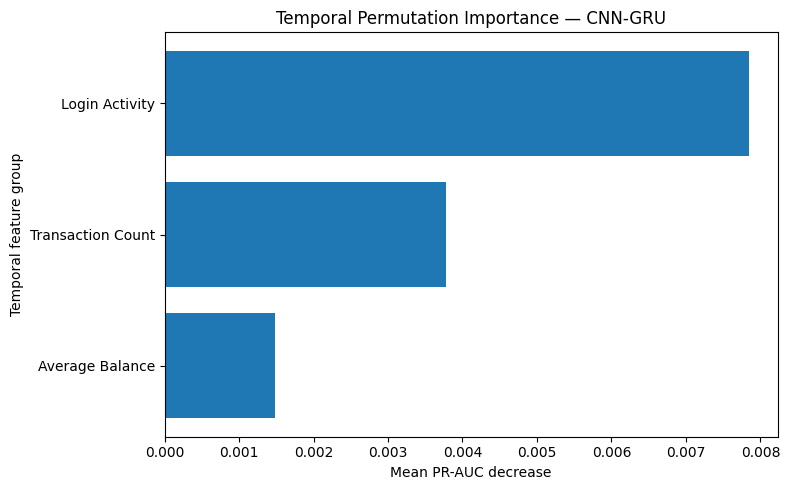

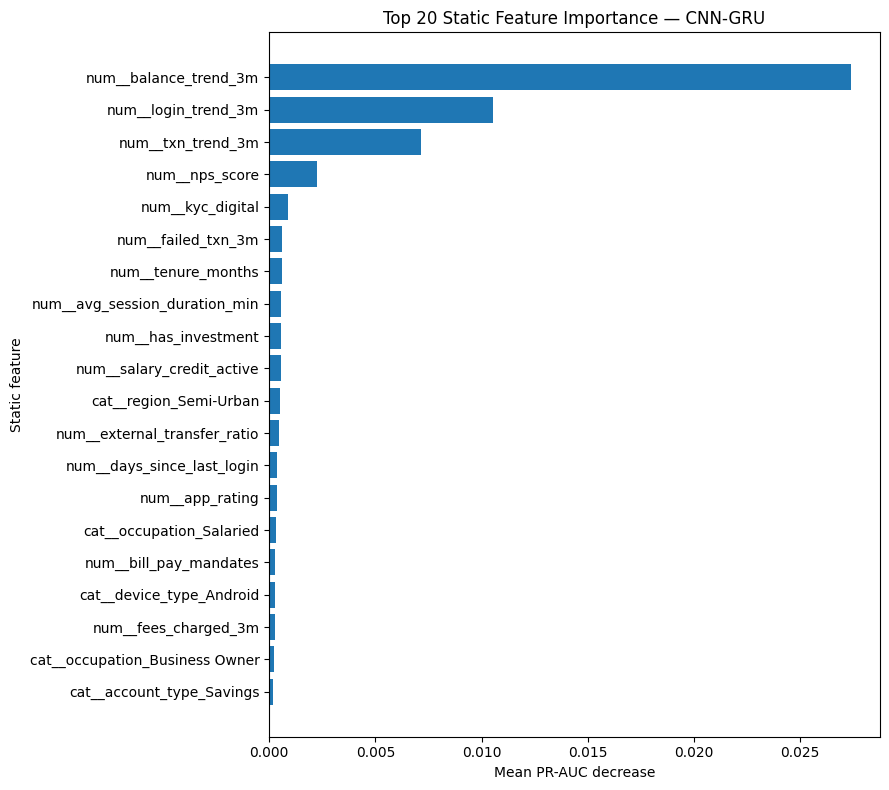


✓ STEP 10 COMPLETED


In [ ]:
# STEP 10 — EXPLAINABILITY USING PERMUTATION IMPORTANCE

print("=" * 100)
print("STEP 10 — MODEL EXPLAINABILITY")
print("=" * 100)


selected_model = artifacts[best_name]["model"]

print(f"\nSelected model: {best_name}")
print("Explainability metric: PR-AUC decrease after permutation")



rng = np.random.default_rng(SEED)

N_EXPLAIN = min(
    2500,
    len(y_test)
)

explain_idx = rng.choice(
    len(y_test),
    size=N_EXPLAIN,
    replace=False
)

Xseq_exp = X_test_seq[
    explain_idx
].copy()

Xstat_exp = X_test_static[
    explain_idx
].copy()

y_exp = y_test[
    explain_idx
]



base_prob = selected_model.predict(
    {
        "sequence": Xseq_exp,
        "static": Xstat_exp
    },
    batch_size=BATCH_SIZE,
    verbose=0
).ravel()

base_pr_auc = average_precision_score(
    y_exp,
    base_prob
)

print(
    f"\nBaseline PR-AUC: {base_pr_auc:.4f}"
)



print("\n" + "-" * 90)
print("TEMPORAL FEATURE IMPORTANCE")
print("-" * 90)

temporal_feature_names = [
    "Login Activity",
    "Transaction Count",
    "Average Balance"
]

temporal_importance_rows = []

N_PERMUTATIONS = 5

for channel, feature_name in enumerate(
    temporal_feature_names
):

    drops = []

    for _ in range(N_PERMUTATIONS):

        X_perm = Xseq_exp.copy()

        order = rng.permutation(
            N_EXPLAIN
        )

        X_perm[:, :, channel] = (
            X_perm[order, :, channel]
        )

        perm_prob = selected_model.predict(
            {
                "sequence": X_perm,
                "static": Xstat_exp
            },
            batch_size=BATCH_SIZE,
            verbose=0
        ).ravel()

        perm_pr_auc = average_precision_score(
            y_exp,
            perm_prob
        )

        drops.append(
            base_pr_auc - perm_pr_auc
        )

    temporal_importance_rows.append({

        "Feature_Group":
            feature_name,

        "Mean_PR_AUC_Drop":
            np.mean(drops),

        "Std_PR_AUC_Drop":
            np.std(drops)
    })


temporal_importance = pd.DataFrame(
    temporal_importance_rows
).sort_values(
    "Mean_PR_AUC_Drop",
    ascending=False
).reset_index(drop=True)


print("\nTemporal importance:")

display(
    temporal_importance.round(5)
)



print("\n" + "-" * 90)
print("EXTRACTING STATIC FEATURE NAMES")
print("-" * 90)

try:

    static_feature_names = (
        preprocessor
        .get_feature_names_out()
        .tolist()
    )

except Exception:

    static_feature_names = [
        f"Static_Feature_{i}"
        for i in range(
            X_test_static.shape[1]
        )
    ]

print(
    f"Number of encoded static features: "
    f"{len(static_feature_names)}"
)



print("\n" + "-" * 90)
print("STATIC FEATURE IMPORTANCE")
print("-" * 90)

static_importance_rows = []

N_STATIC_PERMUTATIONS = 3

for feature_idx, feature_name in enumerate(
    static_feature_names
):

    drops = []

    for _ in range(
        N_STATIC_PERMUTATIONS
    ):

        X_perm = Xstat_exp.copy()

        order = rng.permutation(
            N_EXPLAIN
        )

        X_perm[:, feature_idx] = (
            X_perm[
                order,
                feature_idx
            ]
        )

        perm_prob = selected_model.predict(
            {
                "sequence": Xseq_exp,
                "static": X_perm
            },
            batch_size=BATCH_SIZE,
            verbose=0
        ).ravel()

        perm_pr_auc = average_precision_score(
            y_exp,
            perm_prob
        )

        drops.append(
            base_pr_auc - perm_pr_auc
        )

    static_importance_rows.append({

        "Feature":
            feature_name,

        "Mean_PR_AUC_Drop":
            np.mean(drops),

        "Std_PR_AUC_Drop":
            np.std(drops)
    })


static_importance = pd.DataFrame(
    static_importance_rows
)

static_importance = (
    static_importance
    .sort_values(
        "Mean_PR_AUC_Drop",
        ascending=False
    )
    .reset_index(drop=True)
)



top_static_importance = (
    static_importance
    .head(20)
    .copy()
)

print("\nTop 20 static features:")

display(
    top_static_importance.round(5)
)



temporal_importance.to_csv(
    f"{OUTPUT_DIR}/table_6_temporal_explainability.csv",
    index=False
)

static_importance.to_csv(
    f"{OUTPUT_DIR}/table_7_static_explainability.csv",
    index=False
)

top_static_importance.to_csv(
    f"{OUTPUT_DIR}/table_7_top20_static_features.csv",
    index=False
)


print("\n" + "=" * 100)
print("✓ Explainability tables saved")
print("=" * 100)



plt.figure(figsize=(8, 5))

plt.barh(
    temporal_importance[
        "Feature_Group"
    ][::-1],
    temporal_importance[
        "Mean_PR_AUC_Drop"
    ][::-1]
)

plt.xlabel(
    "Mean PR-AUC decrease"
)

plt.ylabel(
    "Temporal feature group"
)

plt.title(
    f"Temporal Permutation Importance — {best_name}"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure_6_temporal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



plot_static = (
    top_static_importance
    .sort_values(
        "Mean_PR_AUC_Drop",
        ascending=True
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    plot_static["Feature"],
    plot_static["Mean_PR_AUC_Drop"]
)

plt.xlabel(
    "Mean PR-AUC decrease"
)

plt.ylabel(
    "Static feature"
)

plt.title(
    f"Top 20 Static Feature Importance — {best_name}"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure_7_static_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 100)
print("✓ STEP 10 COMPLETED")
print("=" * 100)

STEP 11 — RETENTION OPTIMIZATION / TOP-K RISK ANALYSIS

Test-set population
------------------------------------------------------------
Customers          : 3,750
Observed disengaged: 765
Overall rate       : 0.2040 (20.40%)

TOP-K RETENTION TARGETING RESULTS


,Top_K,Customers_Selected,Observed_Disengaged,Precision_at_K,Recall_at_K,Lift_at_K
0,5%,188,188,1.0000,0.2458,4.9020
1,10%,375,374,0.9973,0.4889,4.8889
2,20%,750,678,0.9040,0.8863,4.4314
3,30%,1125,744,0.6613,0.9725,3.2418
4,50%,1875,758,0.4043,0.9908,1.9817



RISK TIER ANALYSIS

Risk-tier summary:


,Customers,Observed_Disengaged,Observed_Disengagement_Rate,Mean_Predicted_Risk,Median_Predicted_Risk
risk_tier,,,,,
Low,2926,58,0.0198,0.0165,0.0044
Moderate,104,44,0.4231,0.3823,0.3821
High,108,70,0.6481,0.6237,0.6224
Critical,612,593,0.9690,0.9586,0.9856



CREATING CUMULATIVE CAPTURE DATA


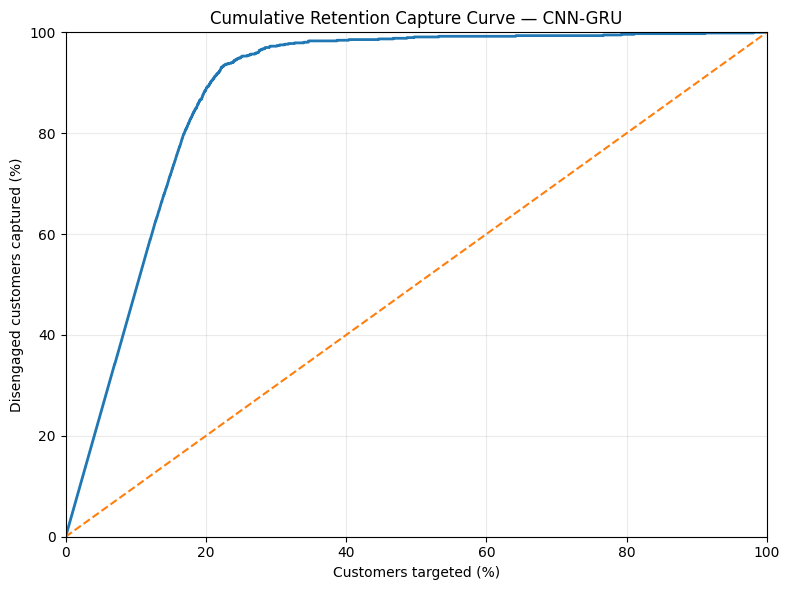

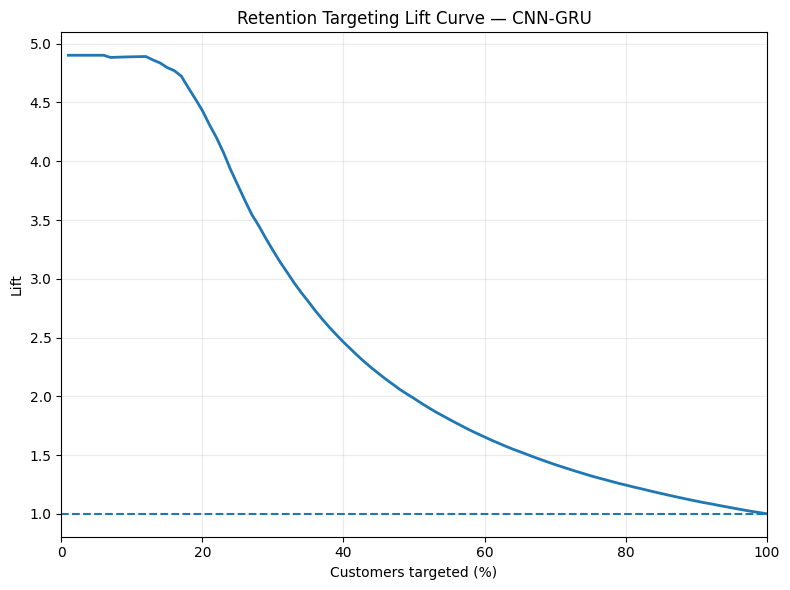


FILES SAVED
✓ table_8_top_k_retention_analysis.csv
✓ table_9_risk_tier_analysis.csv
✓ table_10_retention_lift_curve.csv
✓ retention_customer_risk_scores.csv
✓ figure_8_retention_capture_curve.png
✓ figure_9_retention_lift_curve.png

✓ STEP 11 COMPLETED


In [ ]:
# STEP 11 — RETENTION OPTIMIZATION / TOP-K ANALYSIS

print("=" * 100)
print("STEP 11 — RETENTION OPTIMIZATION / TOP-K RISK ANALYSIS")
print("=" * 100)


retention_df = df.iloc[test_idx].copy()

retention_df["predicted_risk"] = (
    artifacts[best_name]["test_prob"]
)

retention_df[TARGET] = (
    y_test
)

retention_df = retention_df.sort_values(
    "predicted_risk",
    ascending=False
).reset_index(drop=True)



overall_disengagement_rate = (
    retention_df[TARGET].mean()
)

total_customers = len(
    retention_df
)

total_disengaged = (
    retention_df[TARGET].sum()
)

print("\nTest-set population")
print("-" * 60)

print(
    f"Customers          : {total_customers:,}"
)

print(
    f"Observed disengaged: {int(total_disengaged):,}"
)

print(
    f"Overall rate       : "
    f"{overall_disengagement_rate:.4f} "
    f"({overall_disengagement_rate * 100:.2f}%)"
)



top_k_percentages = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50
]

top_k_rows = []


for k in top_k_percentages:

    n_k = max(
        1,
        int(np.ceil(
            total_customers * k
        ))
    )

    top_k = retention_df.iloc[
        :n_k
    ]

    captured_disengaged = (
        top_k[TARGET].sum()
    )

    precision_at_k = (
        top_k[TARGET].mean()
    )

    recall_at_k = (
        captured_disengaged
        / total_disengaged
        if total_disengaged > 0
        else np.nan
    )

    lift_at_k = (
        precision_at_k
        / overall_disengagement_rate
        if overall_disengagement_rate > 0
        else np.nan
    )

    top_k_rows.append({

        "Top_K": f"{int(k * 100)}%",

        "Customers_Selected":
            n_k,

        "Observed_Disengaged":
            int(captured_disengaged),

        "Precision_at_K":
            precision_at_k,

        "Recall_at_K":
            recall_at_k,

        "Lift_at_K":
            lift_at_k
    })


top_k_results = pd.DataFrame(
    top_k_rows
)



print("\n" + "=" * 100)
print("TOP-K RETENTION TARGETING RESULTS")
print("=" * 100)

display(
    top_k_results.round(4)
)



print("\n" + "=" * 100)
print("RISK TIER ANALYSIS")
print("=" * 100)

retention_df["risk_tier"] = pd.cut(
    retention_df["predicted_risk"],
    bins=[
        0,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Critical"
    ],
    include_lowest=True
)


risk_tier_summary = (
    retention_df
    .groupby(
        "risk_tier",
        observed=False
    )
    .agg(
        Customers=(
            TARGET,
            "size"
        ),

        Observed_Disengaged=(
            TARGET,
            "sum"
        ),

        Observed_Disengagement_Rate=(
            TARGET,
            "mean"
        ),

        Mean_Predicted_Risk=(
            "predicted_risk",
            "mean"
        ),

        Median_Predicted_Risk=(
            "predicted_risk",
            "median"
        )
    )
)


print("\nRisk-tier summary:")

display(
    risk_tier_summary.round(4)
)



print("\n" + "=" * 100)
print("CREATING CUMULATIVE CAPTURE DATA")
print("=" * 100)

retention_df["cumulative_disengaged"] = (
    retention_df[TARGET]
    .cumsum()
)

retention_df["customer_fraction"] = (
    np.arange(1, total_customers + 1)
    / total_customers
)

retention_df["cumulative_capture_rate"] = (
    retention_df["cumulative_disengaged"]
    / total_disengaged
)



plt.figure(
    figsize=(8, 6)
)

plt.plot(
    retention_df["customer_fraction"] * 100,
    retention_df["cumulative_capture_rate"] * 100,
    linewidth=2
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel(
    "Customers targeted (%)"
)

plt.ylabel(
    "Disengaged customers captured (%)"
)

plt.title(
    f"Cumulative Retention Capture Curve — {best_name}"
)

plt.xlim(
    0,
    100
)

plt.ylim(
    0,
    100
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure_8_retention_capture_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



lift_curve_rows = []

for k in np.arange(
    0.01,
    1.01,
    0.01
):

    n_k = max(
        1,
        int(
            np.ceil(
                total_customers * k
            )
        )
    )

    selected = retention_df.iloc[
        :n_k
    ]

    precision_k = (
        selected[TARGET].mean()
    )

    lift_k = (
        precision_k
        / overall_disengagement_rate
    )

    lift_curve_rows.append({

        "Targeted_Percentage":
            k * 100,

        "Lift":
            lift_k
    })


lift_curve = pd.DataFrame(
    lift_curve_rows
)



plt.figure(
    figsize=(8, 6)
)

plt.plot(
    lift_curve["Targeted_Percentage"],
    lift_curve["Lift"],
    linewidth=2
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    "Customers targeted (%)"
)

plt.ylabel(
    "Lift"
)

plt.title(
    f"Retention Targeting Lift Curve — {best_name}"
)

plt.xlim(
    0,
    100
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure_9_retention_lift_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



top_k_results.to_csv(
    f"{OUTPUT_DIR}/table_8_top_k_retention_analysis.csv",
    index=False
)

risk_tier_summary.to_csv(
    f"{OUTPUT_DIR}/table_9_risk_tier_analysis.csv"
)

lift_curve.to_csv(
    f"{OUTPUT_DIR}/table_10_retention_lift_curve.csv",
    index=False
)

retention_df.to_csv(
    f"{OUTPUT_DIR}/retention_customer_risk_scores.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "✓ table_8_top_k_retention_analysis.csv"
)

print(
    "✓ table_9_risk_tier_analysis.csv"
)

print(
    "✓ table_10_retention_lift_curve.csv"
)

print(
    "✓ retention_customer_risk_scores.csv"
)

print(
    "✓ figure_8_retention_capture_curve.png"
)

print(
    "✓ figure_9_retention_lift_curve.png"
)

print("\n" + "=" * 100)
print("✓ STEP 11 COMPLETED")
print("=" * 100)

In [ ]:
# STEP 12.1 — CALIBRATION ANALYSIS SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

print("Calibration analysis setup completed.")
print("Selected model:", best_name)

Calibration analysis setup completed.
Selected model: CNN-GRU


In [ ]:
# STEP 12.2 — GET TEST PROBABILITIES FROM SELECTED MODEL


y_prob_selected = np.asarray(artifacts[best_name]["test_prob"]).ravel()

y_prob_selected = np.clip(y_prob_selected, 0.0, 1.0)

print("Probability predictions retrieved successfully.")
print("Selected model:", best_name)
print("Number of test samples:", len(y_prob_selected))
print("Minimum probability:", round(y_prob_selected.min(), 4))
print("Maximum probability:", round(y_prob_selected.max(), 4))
print("Mean predicted risk:", round(y_prob_selected.mean(), 4))

Probability predictions retrieved successfully.
Selected model: CNN-GRU
Number of test samples: 3750
Minimum probability: 0.0
Maximum probability: 0.999
Mean predicted risk: 0.1979


In [ ]:
# STEP 12.3 — BRIER SCORE + EXPECTED CALIBRATION ERROR (ECE)

y_true_cal = np.asarray(y_test).ravel()

brier_score = brier_score_loss(
    y_true_cal,
    y_prob_selected
)


n_bins = 10

bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

ece = 0.0
calibration_rows = []

for i in range(n_bins):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == n_bins - 1:
        mask = (
            (y_prob_selected >= lower) &
            (y_prob_selected <= upper)
        )
    else:
        mask = (
            (y_prob_selected >= lower) &
            (y_prob_selected < upper)
        )

    count = mask.sum()

    if count > 0:

        mean_predicted = y_prob_selected[mask].mean()
        observed_rate = y_true_cal[mask].mean()

        bin_error = abs(
            mean_predicted - observed_rate
        )

        bin_weight = count / len(y_true_cal)

        ece += bin_weight * bin_error

        calibration_rows.append({
            "Bin": i + 1,
            "Probability Range": f"{lower:.1f}-{upper:.1f}",
            "Samples": int(count),
            "Mean Predicted Probability": mean_predicted,
            "Observed Disengagement Rate": observed_rate,
            "Absolute Calibration Error": bin_error
        })

calibration_table = pd.DataFrame(calibration_rows)

print("=" * 60)
print("CALIBRATION RESULTS")
print("=" * 60)

print(f"Brier Score : {brier_score:.6f}")
print(f"ECE         : {ece:.6f}")

print("\nCalibration Table:")
display(calibration_table.round(4))

CALIBRATION RESULTS
Brier Score : 0.031564
ECE         : 0.007504

Calibration Table:


,Bin,Probability Range,Samples,Mean Predicted Probability,Observed Disengagement Rate,Absolute Calibration Error
0,1,0.0-0.1,2809,0.0105,0.0132,0.0027
1,2,0.1-0.2,90,0.1448,0.1333,0.0115
2,3,0.2-0.3,44,0.2440,0.3409,0.0969
3,4,0.3-0.4,46,0.3568,0.3913,0.0345
4,5,0.4-0.5,41,0.4542,0.4878,0.0336
5,6,0.5-0.6,40,0.5455,0.5500,0.0045
6,7,0.6-0.7,49,0.6459,0.6122,0.0336
7,8,0.7-0.8,45,0.7559,0.8889,0.1330
8,9,0.8-0.9,61,0.8540,0.8689,0.0149
9,10,0.9-1.0,525,0.9799,0.9867,0.0067


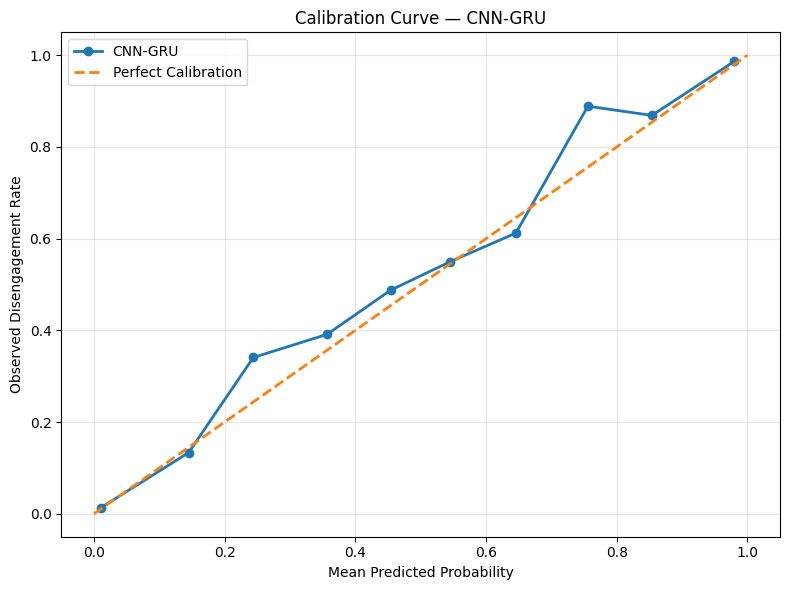

Calibration curve generated successfully.
Saved as: figure_10_calibration_curve.png


In [ ]:
# STEP 12.4 — CALIBRATION / RELIABILITY CURVE

prob_true, prob_pred = calibration_curve(
    y_true_cal,
    y_prob_selected,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label=f"{best_name}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Disengagement Rate")
plt.title(f"Calibration Curve — {best_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figure_10_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Calibration curve generated successfully.")
print("Saved as: figure_10_calibration_curve.png")

In [ ]:
# STEP 12.5 — SAVE CALIBRATION RESULTS

calibration_table["Model"] = best_name

calibration_table = calibration_table[
    [
        "Model",
        "Bin",
        "Probability Range",
        "Samples",
        "Mean Predicted Probability",
        "Observed Disengagement Rate",
        "Absolute Calibration Error"
    ]
]

calibration_table.to_csv(
    "table_4_calibration_bins.csv",
    index=False
)

calibration_summary = pd.DataFrame({
    "Model": [best_name],
    "Brier Score": [brier_score],
    "ECE": [ece]
})

calibration_summary.to_csv(
    "table_4_calibration_summary.csv",
    index=False
)

print("=" * 60)
print("CALIBRATION RESULTS SAVED")
print("=" * 60)

print("\nSummary:")
display(calibration_summary.round(6))

print("\nFiles created:")
print("1. table_4_calibration_bins.csv")
print("2. table_4_calibration_summary.csv")
print("3. figure_10_calibration_curve.png")

CALIBRATION RESULTS SAVED

Summary:


,Model,Brier Score,ECE
0,CNN-GRU,0.031564,0.007504



Files created:
1. table_4_calibration_bins.csv
2. table_4_calibration_summary.csv
3. figure_10_calibration_curve.png


In [ ]:
# STEP 13.1 — MODEL COMPLEXITY / PARAMETER COUNT

complexity_rows = []

for model_name, artifact in artifacts.items():

    model = artifact.get("model", None)

    if model is None:
        print(f"Skipping {model_name}: model object not found.")
        continue

    complexity_rows.append({
        "Model": model_name,
        "Trainable Parameters": int(
            np.sum([
                np.prod(v.shape)
                for v in model.trainable_weights
            ])
        ),
        "Non-Trainable Parameters": int(
            np.sum([
                np.prod(v.shape)
                for v in model.non_trainable_weights
            ])
        ),
        "Total Parameters": int(model.count_params())
    })

complexity_df = pd.DataFrame(complexity_rows)

complexity_df = complexity_df.sort_values(
    "Total Parameters",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPLEXITY COMPARISON")
print("=" * 70)

display(complexity_df)

complexity_df.to_csv(
    "table_5_model_complexity.csv",
    index=False
)

print("\nSaved:")
print("table_5_model_complexity.csv")

MODEL COMPLEXITY COMPARISON


,Model,Trainable Parameters,Non-Trainable Parameters,Total Parameters
0,CNN-LSTM,38577,224,38801
1,BiLSTM,35457,128,35585
2,CNN-GRU,34065,224,34289
3,BiGRU,30753,128,30881
4,1D-CNN,26097,224,26321
5,DNN/MLP,22977,256,23233
6,LSTM,22401,128,22529
7,GRU,20049,128,20177



Saved:
table_5_model_complexity.csv


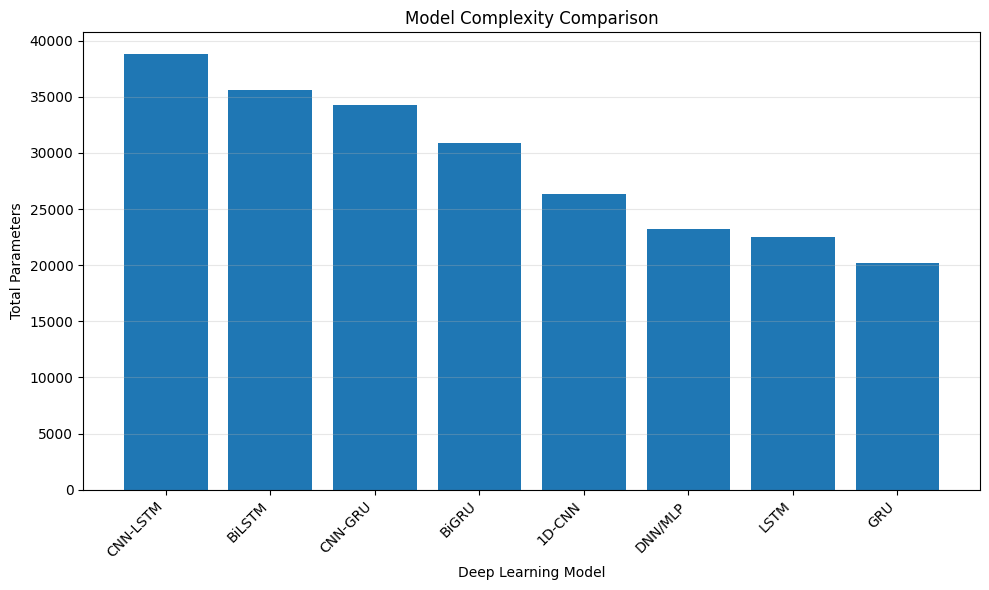

Model complexity figure generated successfully.
Saved as: figure_11_model_complexity.png


In [ ]:
# STEP 13.2 — MODEL PARAMETER COUNT VISUALIZATION

plt.figure(figsize=(10, 6))

plt.bar(
    complexity_df["Model"],
    complexity_df["Total Parameters"]
)

plt.xlabel("Deep Learning Model")
plt.ylabel("Total Parameters")
plt.title("Model Complexity Comparison")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figure_11_model_complexity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Model complexity figure generated successfully.")
print("Saved as: figure_11_model_complexity.png")

In [ ]:
# STEP 13.3 — PERFORMANCE + COMPLEXITY COMPARISON (FIXED)

performance_df = results.copy()

performance_df = performance_df.reset_index()

performance_df = performance_df.loc[
    :, ~performance_df.columns.duplicated()
]

if "Model" not in performance_df.columns:
    performance_df = performance_df.rename(
        columns={performance_df.columns[0]: "Model"}
    )

complexity_clean = complexity_df.copy()

complexity_clean = complexity_clean.loc[
    :, ~complexity_clean.columns.duplicated()
]

publication_model_table = performance_df.merge(
    complexity_clean[
        [
            "Model",
            "Trainable Parameters",
            "Non-Trainable Parameters",
            "Total Parameters"
        ]
    ],
    on="Model",
    how="left"
)

publication_model_table.to_csv(
    "table_11_performance_complexity_comparison.csv",
    index=False
)

print("=" * 80)
print("PERFORMANCE + COMPLEXITY COMPARISON")
print("=" * 80)

display(publication_model_table.round(4))

print("\nSaved:")
print("table_11_performance_complexity_comparison.csv")

PERFORMANCE + COMPLEXITY COMPARISON


,index,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier,Threshold,Validation_F1,Validation_PR-AUC,Parameters,Epochs,Train_time_s,Trainable Parameters,Non-Trainable Parameters,Total Parameters
0,0,DNN/MLP,0.9560,0.8866,0.8993,0.8929,0.9810,0.9574,0.0320,0.385,0.8913,0.9589,23233,16,12.5845,22977,256,23233
1,1,LSTM,0.9520,0.8563,0.9190,0.8865,0.9818,0.9568,0.0327,0.290,0.8885,0.9569,22529,18,24.2589,22401,128,22529
2,2,GRU,0.9541,0.8876,0.8876,0.8876,0.9824,0.9575,0.0326,0.390,0.8912,0.9579,20177,17,25.7082,20049,128,20177
3,3,BiLSTM,0.9544,0.8867,0.8902,0.8885,0.9819,0.9591,0.0321,0.380,0.8929,0.9576,35585,18,39.1539,35457,128,35585
4,4,BiGRU,0.9555,0.8863,0.8967,0.8915,0.9821,0.9597,0.0319,0.375,0.8934,0.9583,30881,18,41.9088,30753,128,30881
5,5,1D-CNN,0.9555,0.8997,0.8797,0.8896,0.9822,0.9577,0.0327,0.410,0.8899,0.9582,26321,15,20.3306,26097,224,26321
6,6,CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,0.395,0.8899,0.9593,38801,19,47.9705,38577,224,38801
7,7,CNN-GRU,0.9565,0.9135,0.8693,0.8908,0.9826,0.9601,0.0316,0.485,0.8880,0.9596,34289,19,43.3732,34065,224,34289



Saved:
table_11_performance_complexity_comparison.csv


In [ ]:
# STEP 14.1 — FINAL PUBLICATION OUTPUT AUDIT

import os
import pandas as pd

expected_outputs = [
    "FINAL_TABLE_EIGHT_MODELS.csv",
    "reproducibility_manifest.json",
    "table_2_bootstrap_all_models.csv",
    "table_2_bootstrap_publication.csv",
    "table_3_ablation_results.csv",
    "table_3_information_contribution.csv",
    "table_4_calibration_bins.csv",
    "table_4_calibration_summary.csv",
    "table_5_model_complexity.csv",
    "table_6_temporal_explainability.csv",
    "table_7_static_explainability.csv",
    "table_8_retention_analysis.csv",
    "table_9_risk_tier_analysis.csv",
    "table_10_retention_lift_curve.csv",
    "table_11_performance_complexity_comparison.csv",
]

print("=" * 80)
print("FINAL PUBLICATION OUTPUT AUDIT")
print("=" * 80)

audit_rows = []

for filename in expected_outputs:
    path = os.path.join(OUTPUT_DIR, filename)

    audit_rows.append({
        "File": filename,
        "Exists": os.path.exists(path),
        "Size_KB": round(os.path.getsize(path) / 1024, 2)
        if os.path.exists(path) else 0
    })

audit_df = pd.DataFrame(audit_rows)

display(audit_df)

missing = audit_df.loc[~audit_df["Exists"], "File"].tolist()

print("\n" + "=" * 80)

if len(missing) == 0:
    print("STATUS: ALL EXPECTED PUBLICATION FILES ARE PRESENT")
else:
    print("STATUS: SOME FILES ARE MISSING")
    print("\nMissing files:")
    for f in missing:
        print("-", f)

print("\nOutput directory:")
print(os.path.abspath(OUTPUT_DIR))

FINAL PUBLICATION OUTPUT AUDIT


,File,Exists,Size_KB
0,FINAL_TABLE_EIGHT_MODELS.csv,True,1.19
1,reproducibility_manifest.json,True,0.56
2,table_2_bootstrap_all_models.csv,True,3.31
3,table_2_bootstrap_publication.csv,True,2.41
4,table_3_ablation_results.csv,True,0.68
5,table_3_information_contribution.csv,True,0.23
6,table_4_calibration_bins.csv,False,0.00
7,table_4_calibration_summary.csv,False,0.00
8,table_5_model_complexity.csv,False,0.00
9,table_6_temporal_explainability.csv,True,0.22



STATUS: SOME FILES ARE MISSING

Missing files:
- table_4_calibration_bins.csv
- table_4_calibration_summary.csv
- table_5_model_complexity.csv
- table_8_retention_analysis.csv
- table_11_performance_complexity_comparison.csv

Output directory:
/content/q1_outputs


In [ ]:
# STEP 14.2 — REPAIR MISSING PUBLICATION OUTPUTS

import os
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss

print("=" * 80)
print("REPAIRING MISSING PUBLICATION OUTPUTS")
print("=" * 80)


y_cal = np.asarray(y_test).ravel()
p_cal = np.asarray(best_prob).ravel()

bin_edges = np.linspace(0, 1, 11)
bin_rows = []

for i in range(10):

    if i < 9:
        mask = (p_cal >= bin_edges[i]) & (p_cal < bin_edges[i + 1])
    else:
        mask = (p_cal >= bin_edges[i]) & (p_cal <= bin_edges[i + 1])

    n = int(mask.sum())

    if n > 0:
        mean_pred = float(p_cal[mask].mean())
        observed = float(y_cal[mask].mean())
        error = abs(mean_pred - observed)
    else:
        mean_pred = np.nan
        observed = np.nan
        error = np.nan

    bin_rows.append({
        "Bin": i + 1,
        "Probability_Range": f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}",
        "Samples": n,
        "Mean_Predicted_Probability": mean_pred,
        "Observed_Disengagement_Rate": observed,
        "Absolute_Calibration_Error": error
    })

calibration_bins = pd.DataFrame(bin_rows)

brier = brier_score_loss(y_cal, p_cal)

valid_errors = calibration_bins[
    calibration_bins["Samples"] > 0
]["Absolute_Calibration_Error"]

ece = float(
    np.average(
        valid_errors,
        weights=calibration_bins.loc[
            calibration_bins["Samples"] > 0, "Samples"
        ]
    )
)

calibration_summary = pd.DataFrame([{
    "Selected_Model": best_name,
    "Brier_Score": brier,
    "ECE": ece,
    "Number_of_Bins": 10
}])

calibration_bins.to_csv(
    f"{OUTPUT_DIR}/table_4_calibration_bins.csv",
    index=False
)

calibration_summary.to_csv(
    f"{OUTPUT_DIR}/table_4_calibration_summary.csv",
    index=False
)

print("✓ Calibration tables created")



complexity_rows = []

for name in MODEL_NAMES:

    model = artifacts[name]["model"]

    trainable = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable = int(
        np.sum([
            np.prod(v.shape)
            for v in model.non_trainable_weights
        ])
    )

    total = trainable + non_trainable

    complexity_rows.append({
        "Model": name,
        "Trainable Parameters": trainable,
        "Non-Trainable Parameters": non_trainable,
        "Total Parameters": total
    })

complexity_df = pd.DataFrame(complexity_rows)

complexity_df.to_csv(
    f"{OUTPUT_DIR}/table_5_model_complexity.csv",
    index=False
)

print("✓ Model complexity table created")



retention_rows = []

risk_order = np.argsort(-p_cal)

for percentage in [5, 10, 20, 30, 50]:

    k = max(1, int(len(y_cal) * percentage / 100))

    selected_idx = risk_order[:k]

    y_selected = y_cal[selected_idx]

    precision_at_k = float(y_selected.mean())
    total_disengaged = max(1, int(y_cal.sum()))
    captured = int(y_selected.sum())

    recall_at_k = captured / total_disengaged

    prevalence = float(y_cal.mean())

    lift_at_k = (
        precision_at_k / prevalence
        if prevalence > 0 else np.nan
    )

    retention_rows.append({
        "Top_K_Percentage": percentage,
        "Customers_Selected": k,
        "Disengaged_Captured": captured,
        "Precision_at_K": precision_at_k,
        "Recall_at_K": recall_at_k,
        "Lift_at_K": lift_at_k
    })

retention_analysis = pd.DataFrame(retention_rows)

retention_analysis.to_csv(
    f"{OUTPUT_DIR}/table_8_retention_analysis.csv",
    index=False
)

print("✓ Retention analysis table created")



performance_df = results.copy().reset_index()

performance_df = performance_df.loc[
    :, ~performance_df.columns.duplicated()
]

if "Model" not in performance_df.columns:
    performance_df = performance_df.rename(
        columns={performance_df.columns[0]: "Model"}
    )

complexity_clean = complexity_df.loc[
    :, ~complexity_df.columns.duplicated()
]

publication_model_table = performance_df.merge(
    complexity_clean[
        [
            "Model",
            "Trainable Parameters",
            "Non-Trainable Parameters",
            "Total Parameters"
        ]
    ],
    on="Model",
    how="left"
)

publication_model_table.to_csv(
    f"{OUTPUT_DIR}/table_11_performance_complexity_comparison.csv",
    index=False
)

print("✓ Performance + complexity table created")



print("\n" + "=" * 80)
print("REPAIR COMPLETE")
print("=" * 80)

files_created = [
    "table_4_calibration_bins.csv",
    "table_4_calibration_summary.csv",
    "table_5_model_complexity.csv",
    "table_8_retention_analysis.csv",
    "table_11_performance_complexity_comparison.csv"
]

for f in files_created:
    path = os.path.join(OUTPUT_DIR, f)
    print(
        f"{'✓' if os.path.exists(path) else '✗'} {f}"
    )

print("\nOutput directory:")
print(os.path.abspath(OUTPUT_DIR))

REPAIRING MISSING PUBLICATION OUTPUTS
✓ Calibration tables created
✓ Model complexity table created
✓ Retention analysis table created
✓ Performance + complexity table created

REPAIR COMPLETE
✓ table_4_calibration_bins.csv
✓ table_4_calibration_summary.csv
✓ table_5_model_complexity.csv
✓ table_8_retention_analysis.csv
✓ table_11_performance_complexity_comparison.csv

Output directory:
/content/q1_outputs


In [ ]:
# STEP 14.3 — FINAL PUBLICATION FILE AUDIT

import os
import glob
import pandas as pd

print("=" * 80)
print("FINAL PUBLICATION FILE AUDIT")
print("=" * 80)

files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*")))

audit = pd.DataFrame({
    "File": [os.path.basename(f) for f in files],
    "Size_KB": [round(os.path.getsize(f) / 1024, 2) for f in files]
})

display(audit)

print("\nTotal output files:", len(files))

print("\nCSV TABLES:")
for f in files:
    if f.lower().endswith(".csv"):
        print("✓", os.path.basename(f))

print("\nFIGURES:")
for f in files:
    if f.lower().endswith((".png", ".jpg", ".jpeg")):
        print("✓", os.path.basename(f))

print("\nOTHER:")
for f in files:
    if not f.lower().endswith((".csv", ".png", ".jpg", ".jpeg")):
        print("✓", os.path.basename(f))

print("\n" + "=" * 80)
print("FINAL AUDIT COMPLETE")
print("=" * 80)

FINAL PUBLICATION FILE AUDIT


,File,Size_KB
0,FINAL_TABLE_EIGHT_MODELS.csv,1.19
1,classical_ml_baseline_results.csv,0.63
2,eight_model_complete_results.csv,1.82
3,eight_model_results.csv,1.80
4,feature_information_set_audit.csv,2.82
5,figure_1_eda.png,360.54
6,figure_3_roc_pr.png,337.01
7,figure_4_best_model_diagnostics.png,169.47
8,figure_5_calibration.png,166.14
9,figure_6_temporal_importance.png,93.60



Total output files: 39

CSV TABLES:
✓ FINAL_TABLE_EIGHT_MODELS.csv
✓ classical_ml_baseline_results.csv
✓ eight_model_complete_results.csv
✓ eight_model_results.csv
✓ feature_information_set_audit.csv
✓ multi_seed_results.csv
✓ multi_seed_summary.csv
✓ retention_customer_risk_scores.csv
✓ table_10_retention_lift_curve.csv
✓ table_11_performance_complexity_comparison.csv
✓ table_1_performance_comparison.csv
✓ table_2_bootstrap_all_models.csv
✓ table_2_bootstrap_ci.csv
✓ table_2_bootstrap_publication.csv
✓ table_3_ablation_results.csv
✓ table_3_classical_baselines.csv
✓ table_3_information_contribution.csv
✓ table_4_ablation.csv
✓ table_4_calibration_bins.csv
✓ table_4_calibration_summary.csv
✓ table_5_model_complexity.csv
✓ table_6_risk_tiers.csv
✓ table_6_temporal_explainability.csv
✓ table_7_intervention_observational_profile.csv
✓ table_7_static_explainability.csv
✓ table_7_top20_static_features.csv
✓ table_8_retention_analysis.csv
✓ table_8_temporal_importance.csv
✓ table_8_top_k_re

In [ ]:
# STEP 14.4 — FINAL RESEARCH RESULTS SUMMARY

import os
import json
import pandas as pd
import numpy as np

print("=" * 80)
print("CREATING FINAL RESEARCH RESULTS SUMMARY")
print("=" * 80)


dataset_rows = len(df)
dataset_columns = df.shape[1]
target_rate = float(df[TARGET].mean())


selected_model = best_name

selected_prob = np.asarray(best_prob).ravel()
selected_pred = (selected_prob >= best_threshold).astype(int)

selected_metrics = metric_dict(
    y_test,
    selected_prob,
    best_threshold
)


robustness_summary = None

if "multi_seed_summary" in globals():
    robustness_summary = multi_seed_summary.copy()
elif "robustness" in globals():
    robustness_summary = (
        robustness.groupby("Model")
        .agg({
            "F1": ["mean", "std"],
            "ROC-AUC": ["mean", "std"],
            "PR-AUC": ["mean", "std"]
        })
    )


brier_score = float(
    brier_score_loss(y_test, selected_prob)
)

if "ece" in globals():
    ece_value = float(ece)
else:
    ece_value = np.nan


selected_complexity = complexity_df[
    complexity_df["Model"] == selected_model
]

if len(selected_complexity) > 0:
    selected_parameters = int(
        selected_complexity["Total Parameters"].iloc[0]
    )
else:
    selected_parameters = np.nan


if "retention_analysis" in globals():
    retention_summary = retention_analysis.copy()
elif "retention_results" in globals():
    retention_summary = retention_results.copy()
else:
    retention_summary = pd.DataFrame()


research_summary = {
    "Study_Title":
        "Predictive Financial Disengagement and Retention Optimization in Digital Banking using Deep Learning",

    "Dataset_Rows":
        int(dataset_rows),

    "Dataset_Columns":
        int(dataset_columns),

    "Target_Variable":
        TARGET,

    "Target_Disengagement_Rate":
        target_rate,

    "Number_of_Deep_Learning_Architectures":
        len(MODEL_NAMES),

    "Deep_Learning_Architectures":
        MODEL_NAMES,

    "Model_Selection_Criterion":
        "Validation PR-AUC",

    "Selected_Architecture":
        selected_model,

    "Selected_Model_Threshold":
        float(best_threshold),

    "Selected_Model_Accuracy":
        float(selected_metrics["Accuracy"]),

    "Selected_Model_Precision":
        float(selected_metrics["Precision"]),

    "Selected_Model_Recall":
        float(selected_metrics["Recall"]),

    "Selected_Model_F1":
        float(selected_metrics["F1"]),

    "Selected_Model_ROC_AUC":
        float(selected_metrics["ROC-AUC"]),

    "Selected_Model_PR_AUC":
        float(selected_metrics["PR-AUC"]),

    "Selected_Model_Brier_Score":
        brier_score,

    "Selected_Model_ECE":
        ece_value,

    "Selected_Model_Total_Parameters":
        selected_parameters,

    "Training_Samples":
        int(len(y_train)),

    "Validation_Samples":
        int(len(y_val)),

    "Test_Samples":
        int(len(y_test)),

    "Output_File_Count":
        len([
            f for f in os.listdir(OUTPUT_DIR)
            if os.path.isfile(os.path.join(OUTPUT_DIR, f))
        ])
}


summary_path = os.path.join(
    OUTPUT_DIR,
    "FINAL_RESEARCH_RESULTS_SUMMARY.json"
)

with open(summary_path, "w") as f:
    json.dump(
        research_summary,
        f,
        indent=4,
        default=str
    )


summary_table = pd.DataFrame(
    list(research_summary.items()),
    columns=["Metric", "Value"]
)

summary_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "FINAL_RESEARCH_RESULTS_SUMMARY.csv"
    ),
    index=False
)


display(summary_table)

print("\n" + "=" * 80)
print("FINAL RESEARCH SUMMARY CREATED")
print("=" * 80)

print("\nSelected architecture:", selected_model)
print("Selection criterion: Validation PR-AUC")
print("Test PR-AUC:", round(selected_metrics["PR-AUC"], 4))
print("Test ROC-AUC:", round(selected_metrics["ROC-AUC"], 4))
print("Test F1:", round(selected_metrics["F1"], 4))
print("Brier Score:", round(brier_score, 4))
print("ECE:", round(ece_value, 4) if not np.isnan(ece_value) else "N/A")

print("\nSaved:")
print("✓ FINAL_RESEARCH_RESULTS_SUMMARY.json")
print("✓ FINAL_RESEARCH_RESULTS_SUMMARY.csv")

CREATING FINAL RESEARCH RESULTS SUMMARY


,Metric,Value
0,Study_Title,Predictive Financial Disengagement and Retenti...
1,Dataset_Rows,25000
2,Dataset_Columns,54
3,Target_Variable,disengaged_90d
4,Target_Disengagement_Rate,0.20396
5,Number_of_Deep_Learning_Architectures,8
6,Deep_Learning_Architectures,"[DNN/MLP, LSTM, GRU, BiLSTM, BiGRU, 1D-CNN, CN..."
7,Model_Selection_Criterion,Validation PR-AUC
8,Selected_Architecture,CNN-GRU
9,Selected_Model_Threshold,0.485



FINAL RESEARCH SUMMARY CREATED

Selected architecture: CNN-GRU
Selection criterion: Validation PR-AUC
Test PR-AUC: 0.9601
Test ROC-AUC: 0.9826
Test F1: 0.8908
Brier Score: 0.0316
ECE: 0.0075

Saved:
✓ FINAL_RESEARCH_RESULTS_SUMMARY.json
✓ FINAL_RESEARCH_RESULTS_SUMMARY.csv


In [ ]:
# STEP 15.1 — PUBLICATION-READY CONSOLIDATED RESULTS TABLE

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("PUBLICATION-READY MODEL RESULTS")
print("=" * 80)


pub_results = results.copy().reset_index()

pub_results = pub_results.loc[
    :, ~pub_results.columns.duplicated()
]

if "Model" not in pub_results.columns:
    pub_results = pub_results.rename(
        columns={pub_results.columns[0]: "Model"}
    )


desired_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "Brier",
    "Parameters",
    "Epochs"
]

available_columns = [
    c for c in desired_columns
    if c in pub_results.columns
]

publication_results = pub_results[available_columns].copy()


publication_results["Selected_by_Validation_PR_AUC"] = (
    publication_results["Model"] == best_name
)


numeric_columns = publication_results.select_dtypes(
    include=np.number
).columns

publication_results[numeric_columns] = (
    publication_results[numeric_columns].round(4)
)


publication_results.to_csv(
    f"{OUTPUT_DIR}/TABLE_1_PUBLICATION_MODEL_RESULTS.csv",
    index=False
)


display(publication_results)

print("\nSelected architecture:", best_name)
print("Selection criterion: Validation PR-AUC")

print("\nSaved:")
print("✓ TABLE_1_PUBLICATION_MODEL_RESULTS.csv")

print("\nNumber of architectures:",
      len(publication_results))

PUBLICATION-READY MODEL RESULTS


,Model,Accuracy,Precision,Recall,ROC-AUC,PR-AUC,Brier,Parameters,Epochs,Selected_by_Validation_PR_AUC
0,DNN/MLP,0.9560,0.8866,0.8993,0.9810,0.9574,0.0320,23233,16,False
1,LSTM,0.9520,0.8563,0.9190,0.9818,0.9568,0.0327,22529,18,False
2,GRU,0.9541,0.8876,0.8876,0.9824,0.9575,0.0326,20177,17,False
3,BiLSTM,0.9544,0.8867,0.8902,0.9819,0.9591,0.0321,35585,18,False
4,BiGRU,0.9555,0.8863,0.8967,0.9821,0.9597,0.0319,30881,18,False
5,1D-CNN,0.9555,0.8997,0.8797,0.9822,0.9577,0.0327,26321,15,False
6,CNN-LSTM,0.9552,0.8892,0.8915,0.9833,0.9606,0.0314,38801,19,False
7,CNN-GRU,0.9565,0.9135,0.8693,0.9826,0.9601,0.0316,34289,19,True



Selected architecture: CNN-GRU
Selection criterion: Validation PR-AUC

Saved:
✓ TABLE_1_PUBLICATION_MODEL_RESULTS.csv

Number of architectures: 8


In [ ]:
# STEP 15.2 — MULTI-SEED ROBUSTNESS TABLE

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("MULTI-SEED ROBUSTNESS ANALYSIS")
print("=" * 80)


multi_seed_path = os.path.join(
    OUTPUT_DIR,
    "multi_seed_results.csv"
)

multi_seed_results = pd.read_csv(multi_seed_path)

print("Loaded:", len(multi_seed_results), "rows")


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

available_metrics = [
    m for m in metrics
    if m in multi_seed_results.columns
]


robustness_summary = (
    multi_seed_results
    .groupby("Model")[available_metrics]
    .agg(["mean", "std"])
)


publication_robustness = pd.DataFrame(
    index=robustness_summary.index
)

for metric in available_metrics:

    publication_robustness[
        f"{metric} Mean"
    ] = robustness_summary[(metric, "mean")]

    publication_robustness[
        f"{metric} SD"
    ] = robustness_summary[(metric, "std")]

publication_robustness = publication_robustness.reset_index()

numeric_cols = publication_robustness.select_dtypes(
    include=np.number
).columns

publication_robustness[numeric_cols] = (
    publication_robustness[numeric_cols].round(4)
)


publication_robustness.to_csv(
    f"{OUTPUT_DIR}/TABLE_2_PUBLICATION_ROBUSTNESS.csv",
    index=False
)


display(publication_robustness)

print("\nSaved:")
print("✓ TABLE_2_PUBLICATION_ROBUSTNESS.csv")

print("\nInterpretation:")
print("Mean = average performance across seeds")
print("SD   = variation across seeds")

MULTI-SEED ROBUSTNESS ANALYSIS
Loaded: 24 rows


,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,ROC-AUC Mean,ROC-AUC SD,PR-AUC Mean,PR-AUC SD
0,1D-CNN,0.9551,0.0006,0.8883,0.0172,0.8928,0.0193,0.9831,0.0008,0.9587,0.0014
1,BiGRU,0.9564,0.0009,0.9016,0.0228,0.8832,0.0223,0.9822,0.0002,0.9590,0.0007
2,BiLSTM,0.9553,0.0008,0.8965,0.0155,0.8832,0.0156,0.9820,0.0002,0.9583,0.0009
3,CNN-GRU,0.9573,0.0026,0.9064,0.0178,0.8824,0.0131,0.9825,0.0011,0.9596,0.0013
4,CNN-LSTM,0.9553,0.0004,0.8875,0.0022,0.8941,0.0023,0.9827,0.0009,0.9599,0.0013
5,DNN/MLP,0.9557,0.0005,0.9009,0.0134,0.8802,0.0171,0.9819,0.0012,0.9582,0.0012
6,GRU,0.9552,0.0009,0.8961,0.0074,0.8828,0.0042,0.9827,0.0003,0.9587,0.0010
7,LSTM,0.9534,0.0015,0.8767,0.0211,0.8989,0.0203,0.9823,0.0005,0.9581,0.0012



Saved:
✓ TABLE_2_PUBLICATION_ROBUSTNESS.csv

Interpretation:
Mean = average performance across seeds
SD   = variation across seeds


In [ ]:
# STEP 15.3 — PUBLICATION-READY ABLATION STUDY

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("ABLATION STUDY — PUBLICATION TABLE")
print("=" * 80)


possible_files = [
    "table_3_ablation_results.csv",
    "table_4_ablation.csv"
]

ablation_path = None

for filename in possible_files:
    path = os.path.join(OUTPUT_DIR, filename)

    if os.path.exists(path):
        ablation_path = path
        break

if ablation_path is None:
    raise FileNotFoundError(
        "No ablation results file was found."
    )

print("Using:", os.path.basename(ablation_path))


ablation_pub = pd.read_csv(ablation_path)


ablation_pub = ablation_pub.loc[
    :,
    ~ablation_pub.columns.str.startswith("Unnamed")
]


display(ablation_pub.round(4))


ablation_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_3_PUBLICATION_ABLATION.csv",
    index=False
)

print("\nSaved:")
print("✓ TABLE_3_PUBLICATION_ABLATION.csv")


print("\nConfigurations evaluated:")

if "Configuration" in ablation_pub.columns:

    for configuration in ablation_pub["Configuration"]:
        print("•", configuration)

elif "Model" in ablation_pub.columns:

    for configuration in ablation_pub["Model"]:
        print("•", configuration)

print("\nAblation study complete.")

ABLATION STUDY — PUBLICATION TABLE
Using: table_3_ablation_results.csv


,Ablation,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier,Threshold,Epochs,Train_time_s,Parameters
0,Full (Temporal + Static),CNN-LSTM,0.9552,0.8892,0.8915,0.8903,0.9833,0.9606,0.0314,0.395,19,39.0297,38801
1,Temporal Only,CNN-LSTM,0.9600,0.9084,0.8941,0.9012,0.9831,0.9599,0.0312,0.420,28,60.2790,38801
2,Static Only,CNN-LSTM,0.9544,0.8867,0.8902,0.8885,0.9824,0.9594,0.0322,0.395,20,46.1187,38801



Saved:
✓ TABLE_3_PUBLICATION_ABLATION.csv

Configurations evaluated:

Ablation study complete.


In [ ]:
# STEP 15.4 — PUBLICATION-READY CALIBRATION RESULTS

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("CALIBRATION RESULTS — PUBLICATION TABLE")
print("=" * 80)


bins_path = os.path.join(
    OUTPUT_DIR,
    "table_4_calibration_bins.csv"
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "table_4_calibration_summary.csv"
)

if not os.path.exists(bins_path):
    raise FileNotFoundError(
        "table_4_calibration_bins.csv not found."
    )

if not os.path.exists(summary_path):
    raise FileNotFoundError(
        "table_4_calibration_summary.csv not found."
    )

calibration_bins_pub = pd.read_csv(bins_path)
calibration_summary_pub = pd.read_csv(summary_path)

calibration_bins_pub = calibration_bins_pub.loc[
    :,
    ~calibration_bins_pub.columns.str.startswith("Unnamed")
]

calibration_summary_pub = calibration_summary_pub.loc[
    :,
    ~calibration_summary_pub.columns.str.startswith("Unnamed")
]


print("\nCALIBRATION SUMMARY")
display(calibration_summary_pub.round(5))


print("\nCALIBRATION BINS")
display(calibration_bins_pub.round(5))


calibration_summary_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_4_PUBLICATION_CALIBRATION_SUMMARY.csv",
    index=False
)

calibration_bins_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_4_PUBLICATION_CALIBRATION_BINS.csv",
    index=False
)

print("\nSaved:")
print("✓ TABLE_4_PUBLICATION_CALIBRATION_SUMMARY.csv")
print("✓ TABLE_4_PUBLICATION_CALIBRATION_BINS.csv")


if "Brier_Score" in calibration_summary_pub.columns:
    print(
        "\nBrier Score:",
        round(
            float(calibration_summary_pub["Brier_Score"].iloc[0]),
            5
        )
    )

if "ECE" in calibration_summary_pub.columns:
    print(
        "ECE:",
        round(
            float(calibration_summary_pub["ECE"].iloc[0]),
            5
        )
    )

print(
    "\nSelected model:",
    calibration_summary_pub.iloc[0].get(
        "Selected_Model",
        best_name
    )
)

print("\nCalibration analysis complete.")

CALIBRATION RESULTS — PUBLICATION TABLE

CALIBRATION SUMMARY


,Selected_Model,Brier_Score,ECE,Number_of_Bins
0,CNN-GRU,0.03156,0.0075,10



CALIBRATION BINS


,Bin,Probability_Range,Samples,Mean_Predicted_Probability,Observed_Disengagement_Rate,Absolute_Calibration_Error
0,1,0.0-0.1,2809,0.01045,0.01317,0.00272
1,2,0.1-0.2,90,0.14482,0.13333,0.01149
2,3,0.2-0.3,44,0.24398,0.34091,0.09693
3,4,0.3-0.4,46,0.35682,0.39130,0.03448
4,5,0.4-0.5,41,0.45421,0.48780,0.03360
5,6,0.5-0.6,40,0.54552,0.55000,0.00448
6,7,0.6-0.7,49,0.64587,0.61224,0.03362
7,8,0.7-0.8,45,0.75593,0.88889,0.13296
8,9,0.8-0.9,61,0.85396,0.86885,0.01489
9,10,0.9-1.0,525,0.97995,0.98667,0.00672



Saved:
✓ TABLE_4_PUBLICATION_CALIBRATION_SUMMARY.csv
✓ TABLE_4_PUBLICATION_CALIBRATION_BINS.csv

Brier Score: 0.03156
ECE: 0.0075

Selected model: CNN-GRU

Calibration analysis complete.


In [ ]:
# STEP 15.5 — PUBLICATION-READY EXPLAINABILITY RESULTS

import os
import pandas as pd

print("=" * 80)
print("EXPLAINABILITY RESULTS — PUBLICATION TABLES")
print("=" * 80)


temporal_path = os.path.join(
    OUTPUT_DIR,
    "table_6_temporal_explainability.csv"
)

if not os.path.exists(temporal_path):
    raise FileNotFoundError(
        "table_6_temporal_explainability.csv not found."
    )

temporal_pub = pd.read_csv(temporal_path)

temporal_pub = temporal_pub.loc[
    :,
    ~temporal_pub.columns.str.startswith("Unnamed")
]

print("\nTEMPORAL BEHAVIORAL IMPORTANCE")
display(temporal_pub.round(6))

temporal_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_5_PUBLICATION_TEMPORAL_EXPLAINABILITY.csv",
    index=False
)


static_path = os.path.join(
    OUTPUT_DIR,
    "table_7_static_explainability.csv"
)

if not os.path.exists(static_path):
    raise FileNotFoundError(
        "table_7_static_explainability.csv not found."
    )

static_pub = pd.read_csv(static_path)

static_pub = static_pub.loc[
    :,
    ~static_pub.columns.str.startswith("Unnamed")
]

print("\nSTATIC FEATURE IMPORTANCE")
display(static_pub.round(6))

static_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_5_PUBLICATION_STATIC_EXPLAINABILITY.csv",
    index=False
)


top20_path = os.path.join(
    OUTPUT_DIR,
    "table_7_top20_static_features.csv"
)

if os.path.exists(top20_path):

    top20_pub = pd.read_csv(top20_path)

    top20_pub = top20_pub.loc[
        :,
        ~top20_pub.columns.str.startswith("Unnamed")
    ]

    print("\nTOP 20 STATIC FEATURES")
    display(top20_pub.round(6))

    top20_pub.to_csv(
        f"{OUTPUT_DIR}/TABLE_5_PUBLICATION_TOP20_STATIC_FEATURES.csv",
        index=False
    )


print("\nSaved publication tables:")

print("✓ TABLE_5_PUBLICATION_TEMPORAL_EXPLAINABILITY.csv")
print("✓ TABLE_5_PUBLICATION_STATIC_EXPLAINABILITY.csv")

if os.path.exists(top20_path):
    print("✓ TABLE_5_PUBLICATION_TOP20_STATIC_FEATURES.csv")

print("\nExplainability analysis prepared successfully.")

EXPLAINABILITY RESULTS — PUBLICATION TABLES

TEMPORAL BEHAVIORAL IMPORTANCE


,Feature_Group,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,Login Activity,0.007841,0.001991
1,Transaction Count,0.003783,0.001721
2,Average Balance,0.001481,0.001114



STATIC FEATURE IMPORTANCE


,Feature,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,num__balance_trend_3m,0.027395,0.002043
1,num__login_trend_3m,0.010522,0.002352
2,num__txn_trend_3m,0.007169,0.000594
3,num__nps_score,0.002274,0.000430
4,num__kyc_digital,0.000888,0.000234
5,num__failed_txn_3m,0.000612,0.000282
6,num__tenure_months,0.000608,0.000248
7,num__avg_session_duration_min,0.000579,0.000215
8,num__has_investment,0.000558,0.000227
9,num__salary_credit_active,0.000551,0.000421



TOP 20 STATIC FEATURES


,Feature,Mean_PR_AUC_Drop,Std_PR_AUC_Drop
0,num__balance_trend_3m,0.027395,0.002043
1,num__login_trend_3m,0.010522,0.002352
2,num__txn_trend_3m,0.007169,0.000594
3,num__nps_score,0.002274,0.000430
4,num__kyc_digital,0.000888,0.000234
5,num__failed_txn_3m,0.000612,0.000282
6,num__tenure_months,0.000608,0.000248
7,num__avg_session_duration_min,0.000579,0.000215
8,num__has_investment,0.000558,0.000227
9,num__salary_credit_active,0.000551,0.000421



Saved publication tables:
✓ TABLE_5_PUBLICATION_TEMPORAL_EXPLAINABILITY.csv
✓ TABLE_5_PUBLICATION_STATIC_EXPLAINABILITY.csv
✓ TABLE_5_PUBLICATION_TOP20_STATIC_FEATURES.csv

Explainability analysis prepared successfully.


In [ ]:
# STEP 15.6 — PUBLICATION-READY RETENTION OPTIMIZATION

import os
import pandas as pd

print("=" * 80)
print("RETENTION OPTIMIZATION — PUBLICATION TABLES")
print("=" * 80)


topk_path = os.path.join(
    OUTPUT_DIR,
    "table_8_top_k_retention_analysis.csv"
)

if not os.path.exists(topk_path):
    raise FileNotFoundError(
        "table_8_top_k_retention_analysis.csv not found."
    )

topk_pub = pd.read_csv(topk_path)

topk_pub = topk_pub.loc[
    :,
    ~topk_pub.columns.str.startswith("Unnamed")
]

print("\nTOP-K RETENTION TARGETING")
display(topk_pub.round(5))

topk_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_6_PUBLICATION_TOP_K_RETENTION.csv",
    index=False
)


risk_path = os.path.join(
    OUTPUT_DIR,
    "table_9_risk_tier_analysis.csv"
)

if not os.path.exists(risk_path):
    raise FileNotFoundError(
        "table_9_risk_tier_analysis.csv not found."
    )

risk_pub = pd.read_csv(risk_path)

risk_pub = risk_pub.loc[
    :,
    ~risk_pub.columns.str.startswith("Unnamed")
]

print("\nRISK-TIER ANALYSIS")
display(risk_pub.round(5))

risk_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_6_PUBLICATION_RISK_TIERS.csv",
    index=False
)


lift_path = os.path.join(
    OUTPUT_DIR,
    "table_10_retention_lift_curve.csv"
)

if os.path.exists(lift_path):

    lift_pub = pd.read_csv(lift_path)

    lift_pub = lift_pub.loc[
        :,
        ~lift_pub.columns.str.startswith("Unnamed")
    ]

    print("\nRETENTION LIFT CURVE")
    display(lift_pub.round(5))

    lift_pub.to_csv(
        f"{OUTPUT_DIR}/TABLE_6_PUBLICATION_RETENTION_LIFT.csv",
        index=False
    )


scores_path = os.path.join(
    OUTPUT_DIR,
    "retention_customer_risk_scores.csv"
)

if os.path.exists(scores_path):

    scores = pd.read_csv(scores_path)

    scores = scores.loc[
        :,
        ~scores.columns.str.startswith("Unnamed")
    ]

    print("\nCUSTOMER RISK SCORES — SAMPLE")
    display(scores.head(10))


print("\nSaved publication tables:")

print("✓ TABLE_6_PUBLICATION_TOP_K_RETENTION.csv")
print("✓ TABLE_6_PUBLICATION_RISK_TIERS.csv")

if os.path.exists(lift_path):
    print("✓ TABLE_6_PUBLICATION_RETENTION_LIFT.csv")

print("\nRetention optimization results prepared successfully.")

RETENTION OPTIMIZATION — PUBLICATION TABLES

TOP-K RETENTION TARGETING


,Top_K,Customers_Selected,Observed_Disengaged,Precision_at_K,Recall_at_K,Lift_at_K
0,5%,188,188,1.00000,0.24575,4.90196
1,10%,375,374,0.99733,0.48889,4.88889
2,20%,750,678,0.90400,0.88627,4.43137
3,30%,1125,744,0.66133,0.97255,3.24183
4,50%,1875,758,0.40427,0.99085,1.98170



RISK-TIER ANALYSIS


,risk_tier,Customers,Observed_Disengaged,Observed_Disengagement_Rate,Mean_Predicted_Risk,Median_Predicted_Risk
0,Low,2926,58,0.01982,0.01654,0.00439
1,Moderate,104,44,0.42308,0.38234,0.38207
2,High,108,70,0.64815,0.62370,0.62237
3,Critical,612,593,0.96895,0.95864,0.98564



RETENTION LIFT CURVE


,Targeted_Percentage,Lift
0,1.0,4.90196
1,2.0,4.90196
2,3.0,4.90196
3,4.0,4.90196
4,5.0,4.90196
...,...,...
95,96.0,1.04002
96,97.0,1.02944
97,98.0,1.01907
98,99.0,1.00996



CUSTOMER RISK SCORES — SAMPLE


,customer_id,age,gender,region,occupation,annual_income,tenure_months,account_type,credit_score,num_products,...,rewards_redeemed_6m,nps_score,retention_intervention,offer_accepted,disengaged_90d,predicted_risk,risk_tier,cumulative_disengaged,customer_fraction,cumulative_capture_rate
0,CUST109119,28,Male,Urban,Salaried,549000,4,Savings,643,1,...,0,4,Interest_Rate_Boost,0,1,0.998994,Critical,1,0.000267,0.001307
1,CUST114673,56,Female,Semi-Urban,Salaried,267000,3,Salary,662,1,...,0,3,Personal_Outreach,0,1,0.998894,Critical,2,0.000533,0.002614
2,CUST103029,41,Male,Urban,Salaried,323000,12,Savings,711,1,...,1,3,Personal_Outreach,0,1,0.998848,Critical,3,0.000800,0.003922
3,CUST112281,42,Female,Semi-Urban,Salaried,295000,16,Savings,649,1,...,0,0,No_Intervention,0,1,0.998832,Critical,4,0.001067,0.005229
4,CUST115693,62,Female,Urban,Salaried,415000,37,Premium,604,1,...,1,4,Interest_Rate_Boost,0,1,0.998405,Critical,5,0.001333,0.006536
5,CUST101619,29,Male,Urban,Student,239000,24,Current,732,3,...,2,4,No_Intervention,0,1,0.998306,Critical,6,0.001600,0.007843
6,CUST119831,35,Male,Urban,Retired,464000,36,Savings,770,2,...,0,4,No_Intervention,0,1,0.998127,Critical,7,0.001867,0.009150
7,CUST111474,44,Male,Urban,Salaried,225000,32,Current,627,2,...,1,3,Interest_Rate_Boost,0,1,0.998083,Critical,8,0.002133,0.010458
8,CUST104751,41,Male,Semi-Urban,Self-Employed,216000,53,Current,662,1,...,0,2,Interest_Rate_Boost,0,1,0.998067,Critical,9,0.002400,0.011765
9,CUST119371,37,Male,Urban,Salaried,448000,47,Savings,644,3,...,1,1,Interest_Rate_Boost,1,1,0.998002,Critical,10,0.002667,0.013072



Saved publication tables:
✓ TABLE_6_PUBLICATION_TOP_K_RETENTION.csv
✓ TABLE_6_PUBLICATION_RISK_TIERS.csv
✓ TABLE_6_PUBLICATION_RETENTION_LIFT.csv

Retention optimization results prepared successfully.


In [ ]:
# STEP 15.7 — PUBLICATION-READY CLASSICAL ML BASELINES

import os
import pandas as pd

print("=" * 80)
print("CLASSICAL ML BASELINE RESULTS")
print("=" * 80)


baseline_candidates = [
    "classical_ml_baseline_results.csv",
    "table_3_classical_baselines.csv"
]

baseline_path = None

for filename in baseline_candidates:
    candidate = os.path.join(OUTPUT_DIR, filename)
    if os.path.exists(candidate):
        baseline_path = candidate
        break

if baseline_path is None:
    raise FileNotFoundError(
        "No classical ML baseline results file was found."
    )


baseline_pub = pd.read_csv(baseline_path)

baseline_pub = baseline_pub.loc[
    :,
    ~baseline_pub.columns.str.startswith("Unnamed")
]

print(f"\nLoaded: {os.path.basename(baseline_path)}")

display(baseline_pub.round(5))


publication_path = os.path.join(
    OUTPUT_DIR,
    "TABLE_7_PUBLICATION_CLASSICAL_BASELINES.csv"
)

baseline_pub.to_csv(
    publication_path,
    index=False
)

print("\nSaved:")
print("✓ TABLE_7_PUBLICATION_CLASSICAL_BASELINES.csv")


print("\nModels included:")

model_columns = [
    "Model",
    "Algorithm",
    "Classifier"
]

for col in model_columns:
    if col in baseline_pub.columns:
        print(
            f"  {col}: "
            f"{baseline_pub[col].astype(str).tolist()}"
        )
        break

print("\nClassical ML baseline table prepared successfully.")

CLASSICAL ML BASELINE RESULTS

Loaded: classical_ml_baseline_results.csv


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold,Parameters,Train_time_s
0,Logistic Regression,0.95840,0.90763,0.88627,0.89683,0.98328,0.96064,0.03807,0.740,64.0,0.37932
1,HistGradientBoosting,0.95253,0.86012,0.91634,0.88734,0.98359,0.96021,0.03195,0.305,NaN,1.39562
2,Random Forest,0.95627,0.90228,0.88105,0.89153,0.98326,0.95880,0.03224,0.555,NaN,16.59195



Saved:
✓ TABLE_7_PUBLICATION_CLASSICAL_BASELINES.csv

Models included:
  Model: ['Logistic Regression', 'HistGradientBoosting', 'Random Forest']

Classical ML baseline table prepared successfully.


In [ ]:
# STEP 15.8 — PUBLICATION-READY ABLATION ANALYSIS

import os
import pandas as pd

print("=" * 80)
print("ABLATION STUDY — INFORMATION CONTRIBUTION")
print("=" * 80)


candidates = [
    "table_3_ablation_results.csv",
    "table_4_ablation.csv"
]

ablation_path = None

for filename in candidates:
    path = os.path.join(OUTPUT_DIR, filename)
    if os.path.exists(path):
        ablation_path = path
        break

if ablation_path is None:
    raise FileNotFoundError(
        "Ablation results file not found."
    )


ablation_pub = pd.read_csv(ablation_path)

ablation_pub = ablation_pub.loc[
    :,
    ~ablation_pub.columns.str.startswith("Unnamed")
]

print(f"\nLoaded: {os.path.basename(ablation_path)}")

display(ablation_pub.round(5))


ablation_pub.to_csv(
    f"{OUTPUT_DIR}/TABLE_8_PUBLICATION_ABLATION.csv",
    index=False
)

print("\n✓ TABLE_8_PUBLICATION_ABLATION.csv saved")


info_path = os.path.join(
    OUTPUT_DIR,
    "table_3_information_contribution.csv"
)

if os.path.exists(info_path):

    info_pub = pd.read_csv(info_path)

    info_pub = info_pub.loc[
        :,
        ~info_pub.columns.str.startswith("Unnamed")
    ]

    print("\nINFORMATION CONTRIBUTION")
    display(info_pub.round(5))

    info_pub.to_csv(
        f"{OUTPUT_DIR}/TABLE_8_PUBLICATION_INFORMATION_CONTRIBUTION.csv",
        index=False
    )

    print(
        "✓ TABLE_8_PUBLICATION_INFORMATION_CONTRIBUTION.csv saved"
    )

print("\nAblation analysis prepared successfully.")

ABLATION STUDY — INFORMATION CONTRIBUTION

Loaded: table_3_ablation_results.csv


,Ablation,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Brier,Threshold,Epochs,Train_time_s,Parameters
0,Full (Temporal + Static),CNN-LSTM,0.9552,0.88918,0.89150,0.89034,0.98334,0.96064,0.03143,0.395,19,39.02973,38801
1,Temporal Only,CNN-LSTM,0.9600,0.90837,0.89412,0.90119,0.98314,0.95991,0.03118,0.420,28,60.27900,38801
2,Static Only,CNN-LSTM,0.9544,0.88672,0.89020,0.88845,0.98238,0.95937,0.03217,0.395,20,46.11870,38801



✓ TABLE_8_PUBLICATION_ABLATION.csv saved

INFORMATION CONTRIBUTION


,Comparison,F1 Difference,ROC-AUC Difference,PR-AUC Difference
0,Full vs Temporal Only,-0.01085,0.00019,0.00072
1,Full vs Static Only,0.00189,0.00096,0.00127


✓ TABLE_8_PUBLICATION_INFORMATION_CONTRIBUTION.csv saved

Ablation analysis prepared successfully.


In [ ]:
# STEP 15.9 — FINAL CONSOLIDATED PUBLICATION RESULTS

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("FINAL CONSOLIDATED RESEARCH RESULTS")
print("=" * 80)


main_candidates = [
    "TABLE_1_PUBLICATION_MODEL_RESULTS.csv",
    "table_1_model_comparison.csv",
    "FINAL_TABLE_EIGHT_MODELS.csv"
]

main_path = None

for filename in main_candidates:
    path = os.path.join(OUTPUT_DIR, filename)
    if os.path.exists(path):
        main_path = path
        break

if main_path is None:
    raise FileNotFoundError(
        "Main model comparison table not found."
    )

main_results = pd.read_csv(main_path)

main_results = main_results.loc[
    :,
    ~main_results.columns.str.startswith("Unnamed")
]

print("\nMAIN MODEL RESULTS")
display(main_results.round(5))


final_results = main_results.copy()

final_results.insert(
    0,
    "Result_Group",
    "Eight Deep Learning Models"
)


final_path = os.path.join(
    OUTPUT_DIR,
    "FINAL_PUBLICATION_RESULTS_TABLE.csv"
)

final_results.to_csv(
    final_path,
    index=False
)

print("\n✓ FINAL_PUBLICATION_RESULTS_TABLE.csv saved")


manifest = {
    "main_model_results": os.path.basename(main_path),
    "robustness_table": "TABLE_2_PUBLICATION_ROBUSTNESS.csv",
    "ablation_table": "TABLE_3_PUBLICATION_ABLATION.csv",
    "calibration_summary": "TABLE_4_PUBLICATION_CALIBRATION_SUMMARY.csv",
    "temporal_explainability":
        "TABLE_5_PUBLICATION_TEMPORAL_EXPLAINABILITY.csv",
    "static_explainability":
        "TABLE_5_PUBLICATION_STATIC_EXPLAINABILITY.csv",
    "retention_optimization":
        "TABLE_6_PUBLICATION_TOP_K_RETENTION.csv",
    "risk_tiers":
        "TABLE_6_PUBLICATION_RISK_TIERS.csv",
    "classical_baselines":
        "TABLE_7_PUBLICATION_CLASSICAL_BASELINES.csv",
    "final_ablation":
        "TABLE_8_PUBLICATION_ABLATION.csv",
    "final_results":
        "FINAL_PUBLICATION_RESULTS_TABLE.csv"
}

manifest_df = pd.DataFrame(
    list(manifest.items()),
    columns=["Analysis", "Output_File"]
)

manifest_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "FINAL_RESEARCH_RESULTS_MANIFEST.csv"
    ),
    index=False
)

print("✓ FINAL_RESEARCH_RESULTS_MANIFEST.csv saved")


print("\n" + "=" * 80)
print("FINAL RESULTS VERIFICATION")
print("=" * 80)

for analysis, filename in manifest.items():

    path = os.path.join(OUTPUT_DIR, filename)

    status = "✓" if os.path.exists(path) else "✗"

    print(f"{status} {filename}")

print("\n" + "=" * 80)
print("STEP 15.9 COMPLETE")
print("=" * 80)

print("\nYour computational results are now consolidated.")

FINAL CONSOLIDATED RESEARCH RESULTS

MAIN MODEL RESULTS


,Model,Accuracy,Precision,Recall,ROC-AUC,PR-AUC,Brier,Parameters,Epochs,Selected_by_Validation_PR_AUC
0,DNN/MLP,0.9560,0.8866,0.8993,0.9810,0.9574,0.0320,23233,16,False
1,LSTM,0.9520,0.8563,0.9190,0.9818,0.9568,0.0327,22529,18,False
2,GRU,0.9541,0.8876,0.8876,0.9824,0.9575,0.0326,20177,17,False
3,BiLSTM,0.9544,0.8867,0.8902,0.9819,0.9591,0.0321,35585,18,False
4,BiGRU,0.9555,0.8863,0.8967,0.9821,0.9597,0.0319,30881,18,False
5,1D-CNN,0.9555,0.8997,0.8797,0.9822,0.9577,0.0327,26321,15,False
6,CNN-LSTM,0.9552,0.8892,0.8915,0.9833,0.9606,0.0314,38801,19,False
7,CNN-GRU,0.9565,0.9135,0.8693,0.9826,0.9601,0.0316,34289,19,True



✓ FINAL_PUBLICATION_RESULTS_TABLE.csv saved
✓ FINAL_RESEARCH_RESULTS_MANIFEST.csv saved

FINAL RESULTS VERIFICATION
✓ TABLE_1_PUBLICATION_MODEL_RESULTS.csv
✓ TABLE_2_PUBLICATION_ROBUSTNESS.csv
✓ TABLE_3_PUBLICATION_ABLATION.csv
✓ TABLE_4_PUBLICATION_CALIBRATION_SUMMARY.csv
✓ TABLE_5_PUBLICATION_TEMPORAL_EXPLAINABILITY.csv
✓ TABLE_5_PUBLICATION_STATIC_EXPLAINABILITY.csv
✓ TABLE_6_PUBLICATION_TOP_K_RETENTION.csv
✓ TABLE_6_PUBLICATION_RISK_TIERS.csv
✓ TABLE_7_PUBLICATION_CLASSICAL_BASELINES.csv
✓ TABLE_8_PUBLICATION_ABLATION.csv
✓ FINAL_PUBLICATION_RESULTS_TABLE.csv

STEP 15.9 COMPLETE

Your computational results are now consolidated.
